# NHANES Full Dataset — Extensive EDA

**Goals:**
1. Which features are most relevant for `DPQ040` (fatigue severity)?
2. Which features best inform a user questionnaire to predict probability of any of the 15 diseases?
3. Which lab/blood markers are most relevant for each of the 15 diseases?

**Dataset:** `nhanes_merged_adults_final.csv` — 7,437 adults, 868 columns  
**Disease labels:** anemia, diabetes, thyroid, sleep_disorder, kidney, hepatitis_bc, liver, heart_failure, coronary_heart, emphysema_lungs, high_blood_pressure, high_cholesterol, menopause, overweight, alcohol

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency, mannwhitneyu
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
PALETTE = 'Set2'

DATA_PATH = '../data/processed/nhanes_merged_adults_final.csv'
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (7437, 868)


,SEQN,age_years,income_poverty_ratio,mec_exam_weight,interview_weight,survey_psu,survey_stratum,gender,ethnicity,education,...,LBXVTFT_blood_aaa_trifluorotoluene_ng_ml,LBDVFTLC_blood_aaa_trifluorotoluene_comment_code,LBXVTHF_blood_tetrahydrofuran_ng_ml,LBDVHTLC_blood_tetrahydrofuran_comment_code,LBXVTP_blood_1_2_3_trichloropropane_ng_ml,LBDVTPLC_blood_1_2_3_trichloropropane_comt_code,LBXVVB_blood_vinyl_bromide_ng_ml,LBDVVBLC_blood_vinyl_bromide_comment_code,LBXVXY_blood_m_p_xylene_ng_ml,LBDVXYLC_blood_m_p_xylene_comment_code
0,109266,29.0,5.00,8.154968e+03,7825.646112,2.0,168.0,Female,Non-Hispanic Asian,College graduate or above,...,0.028,1.0,0.088,1.0,0.028,1.0,0.032,1.0,0.035,0.0
1,109267,21.0,5.00,5.397605e-79,26379.991724,1.0,156.0,Female,Other Hispanic,Some college / AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109268,18.0,1.66,5.397605e-79,19639.221008,1.0,155.0,Female,Non-Hispanic White,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 1. Dataset Overview

In [2]:
DISEASE_COLS = [
    'anemia','diabetes','thyroid','sleep_disorder','kidney',
    'hepatitis_bc','liver','heart_failure','coronary_heart',
    'emphysema_lungs','high_blood_pressure','high_cholesterol',
    'menopause','overweight','alcohol'
]
TARGET = 'dpq040___feeling_tired_or_having_little_energy'

LAB_COLS = [c for c in df_raw.columns if '_' in c and c.split('_')[0].isupper() and len(c.split('_')[0]) >= 4]
DEMO_COLS = ['age_years','gender','ethnicity','education','marital_status',
             'income_poverty_ratio','country_of_birth','pregnancy_status']
NUTRITION_COLS = ['calories','protein','carbs','fat','iron','vitamin_b12','vitamin_d',
                  'folate','magnesium','zinc']

print(f'Total columns: {df_raw.shape[1]}')
print(f'  Demographics:  {len(DEMO_COLS)}')
print(f'  Nutrition:     {len(NUTRITION_COLS)}')
print(f'  Lab markers:   {len(LAB_COLS)}')
print(f'  Disease labels:{len(DISEASE_COLS)}')
print(f'  Target (DPQ040): present = {TARGET in df_raw.columns}')

Total columns: 868
  Demographics:  8
  Nutrition:     10
  Lab markers:   484
  Disease labels:15
  Target (DPQ040): present = True


In [3]:
# --- Data types ---
dtype_summary = df_raw.dtypes.value_counts()
print('Dtypes:\n', dtype_summary)
print()
# --- Missing data heatmap summary ---
missing = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
buckets = pd.cut(missing, bins=[-0.1,0,20,50,80,100],
                 labels=['0%','1-20%','21-50%','51-80%','>80%'])
print('Missing data distribution:')
print(buckets.value_counts().sort_index())

Dtypes:
 float64    807
str         41
int64       20
Name: count, dtype: int64

Missing data distribution:
0%         69
1-20%     223
21-50%     81
51-80%    338
>80%      157
Name: count, dtype: int64


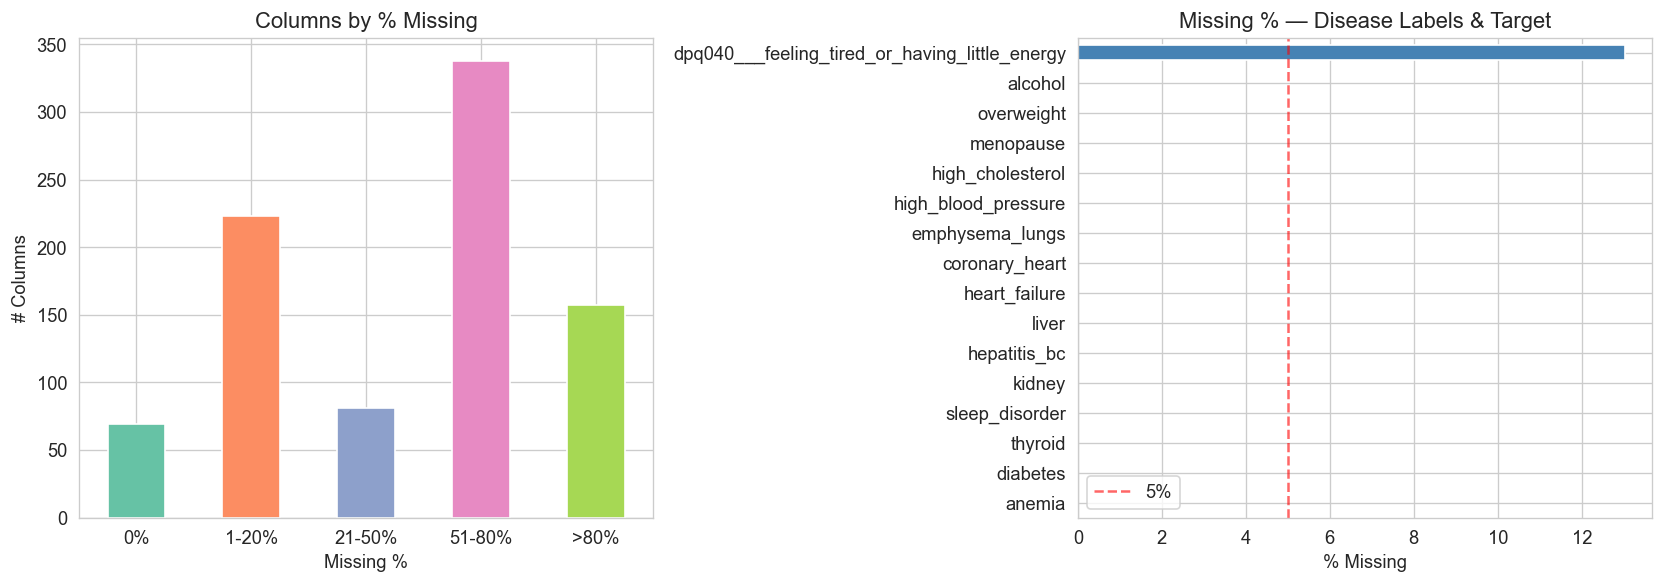


> Expert note: Lab columns have high missingness (>50%) because different sub-studies
  collected different panels. Do NOT impute blindly — use domain-aware strategies.
  For modelling, consider: (a) complete-case analysis per lab panel, or
  (b) MICE/iterative imputation for columns with <40% missing.


In [4]:
# --- Missing data bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of missingness
buckets.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=sns.color_palette(PALETTE))
axes[0].set_title('Columns by % Missing')
axes[0].set_xlabel('Missing %')
axes[0].set_ylabel('# Columns')
axes[0].tick_params(axis='x', rotation=0)

# Right: missingness for disease + target columns
key_cols = DISEASE_COLS + [TARGET]
miss_key = df_raw[key_cols].isnull().sum() / len(df_raw) * 100
miss_key.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Missing % — Disease Labels & Target')
axes[1].set_xlabel('% Missing')
axes[1].axvline(5, color='red', linestyle='--', alpha=0.6, label='5%')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n> Expert note: Lab columns have high missingness (>50%) because different sub-studies')
print('  collected different panels. Do NOT impute blindly — use domain-aware strategies.')
print('  For modelling, consider: (a) complete-case analysis per lab panel, or')
print('  (b) MICE/iterative imputation for columns with <40% missing.')

---
## 2. Target Variable — DPQ040 Fatigue Severity

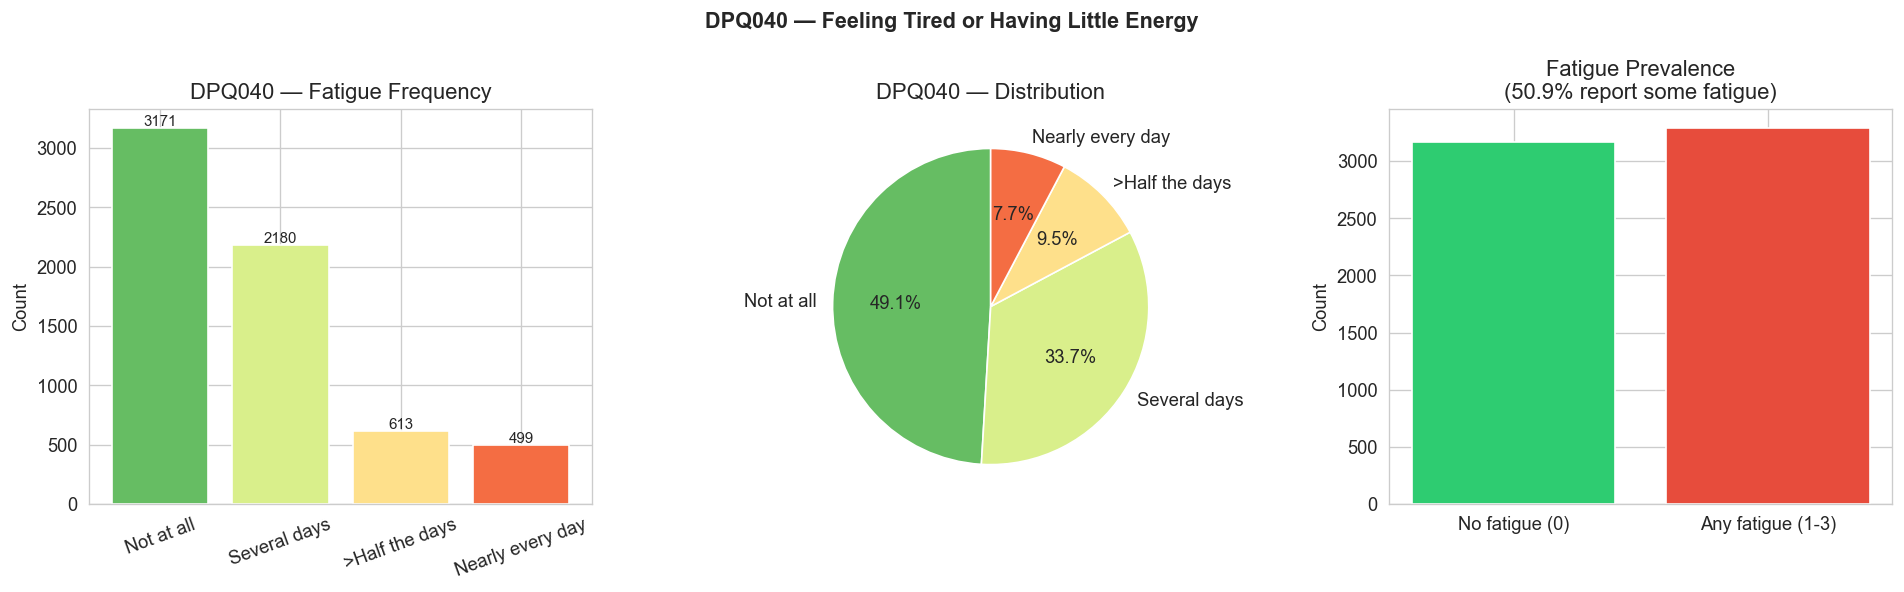


Target stats (0-3 scale):
count    6463.000000
mean        0.758626
std         0.914434
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: dpq040___feeling_tired_or_having_little_energy, dtype: float64

Missing: 974 (13.1%)

> Expert note: DPQ040 is an ordinal variable (0-3). For regression treat as continuous
  or ordinal. For classification, binarise: 0=no fatigue vs 1-3=fatigue.


In [5]:
# DPQ040: 0=Not at all, 1=Several days, 2=More than half the days, 3=Nearly every day
# Recode 7/9 as NaN
df = df_raw.copy()
df[TARGET] = df[TARGET].replace({7: np.nan, 9: np.nan})

label_map = {0:'Not at all', 1:'Several days', 2:'>Half the days', 3:'Nearly every day'}
dpq_counts = df[TARGET].map(label_map).value_counts(dropna=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart
order = ['Not at all','Several days','>Half the days','Nearly every day']
vals = [dpq_counts.get(o, 0) for o in order]
colors = sns.color_palette('RdYlGn_r', 4)
axes[0].bar(order, vals, color=colors)
axes[0].set_title('DPQ040 — Fatigue Frequency')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i,(v,c) in enumerate(zip(vals, order)):
    axes[0].text(i, v+20, str(v), ha='center', fontsize=9)

# Pie
axes[1].pie(vals, labels=order, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('DPQ040 — Distribution')

# Cumulative — % with ANY fatigue (score>=1)
any_fatigue = (df[TARGET] >= 1).sum()
total_valid = df[TARGET].notna().sum()
axes[2].bar(['No fatigue (0)','Any fatigue (1-3)'],
            [total_valid - any_fatigue, any_fatigue],
            color=['#2ecc71','#e74c3c'])
axes[2].set_title(f'Fatigue Prevalence\n({any_fatigue/total_valid*100:.1f}% report some fatigue)')
axes[2].set_ylabel('Count')

plt.suptitle('DPQ040 — Feeling Tired or Having Little Energy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTarget stats (0-3 scale):')
print(df[TARGET].describe())
print(f'\nMissing: {df[TARGET].isna().sum()} ({df[TARGET].isna().mean()*100:.1f}%)')
print('\n> Expert note: DPQ040 is an ordinal variable (0-3). For regression treat as continuous')
print('  or ordinal. For classification, binarise: 0=no fatigue vs 1-3=fatigue.')

---
## 3. Disease Prevalence Overview

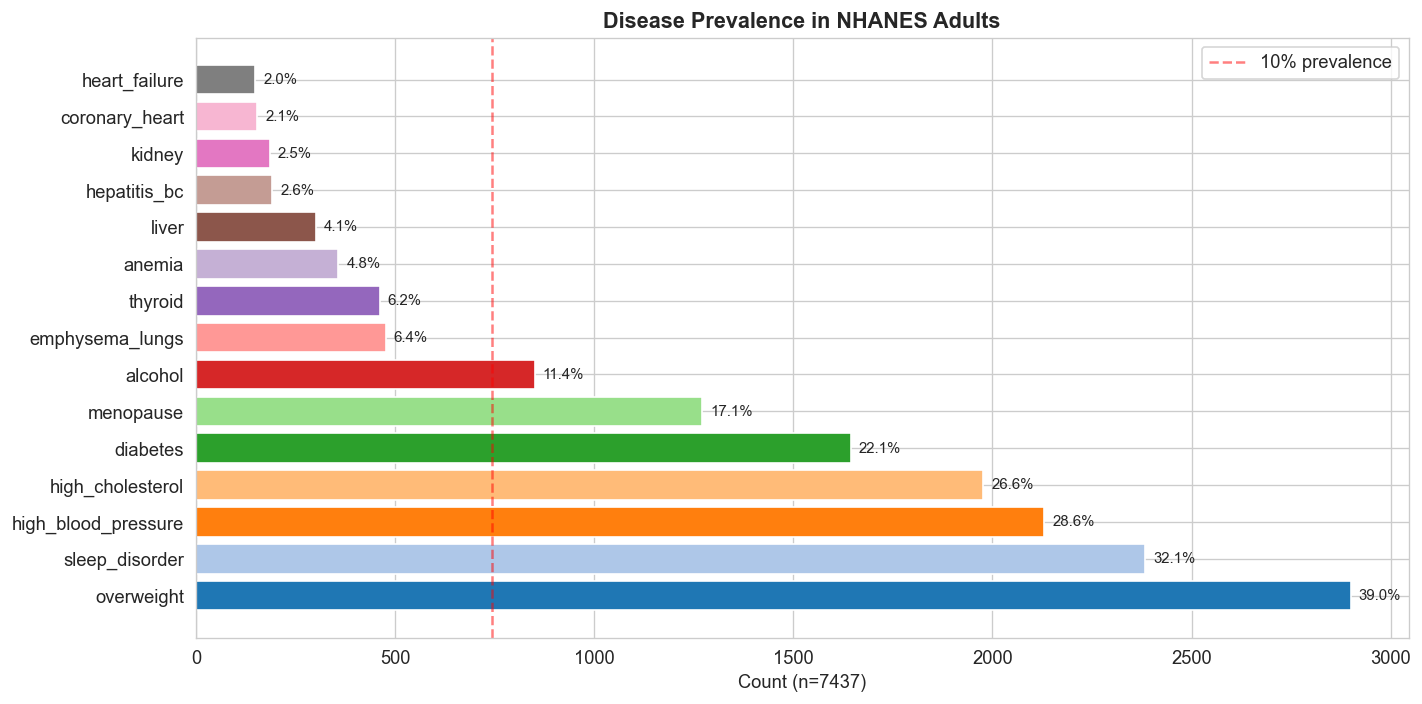


> Expert note: Rare diseases (hepatitis_bc, kidney, heart_failure, coronary_heart) have
  <3% prevalence — heavy class imbalance. Use SMOTE or class_weight=balanced for models.
  Menopause is female-only — always stratify by gender.


In [6]:
disease_prev = df[DISEASE_COLS].sum().sort_values(ascending=False)
disease_pct  = (disease_prev / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('tab20', len(DISEASE_COLS))
bars = ax.barh(disease_prev.index, disease_prev.values, color=colors)
for bar, pct in zip(bars, disease_pct[disease_prev.index]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
ax.set_xlabel('Count (n=7437)')
ax.set_title('Disease Prevalence in NHANES Adults', fontsize=13, fontweight='bold')
ax.axvline(len(df)*0.1, color='red', linestyle='--', alpha=0.5, label='10% prevalence')
ax.legend()
plt.tight_layout()
plt.show()

print('\n> Expert note: Rare diseases (hepatitis_bc, kidney, heart_failure, coronary_heart) have')
print('  <3% prevalence — heavy class imbalance. Use SMOTE or class_weight=balanced for models.')
print('  Menopause is female-only — always stratify by gender.')

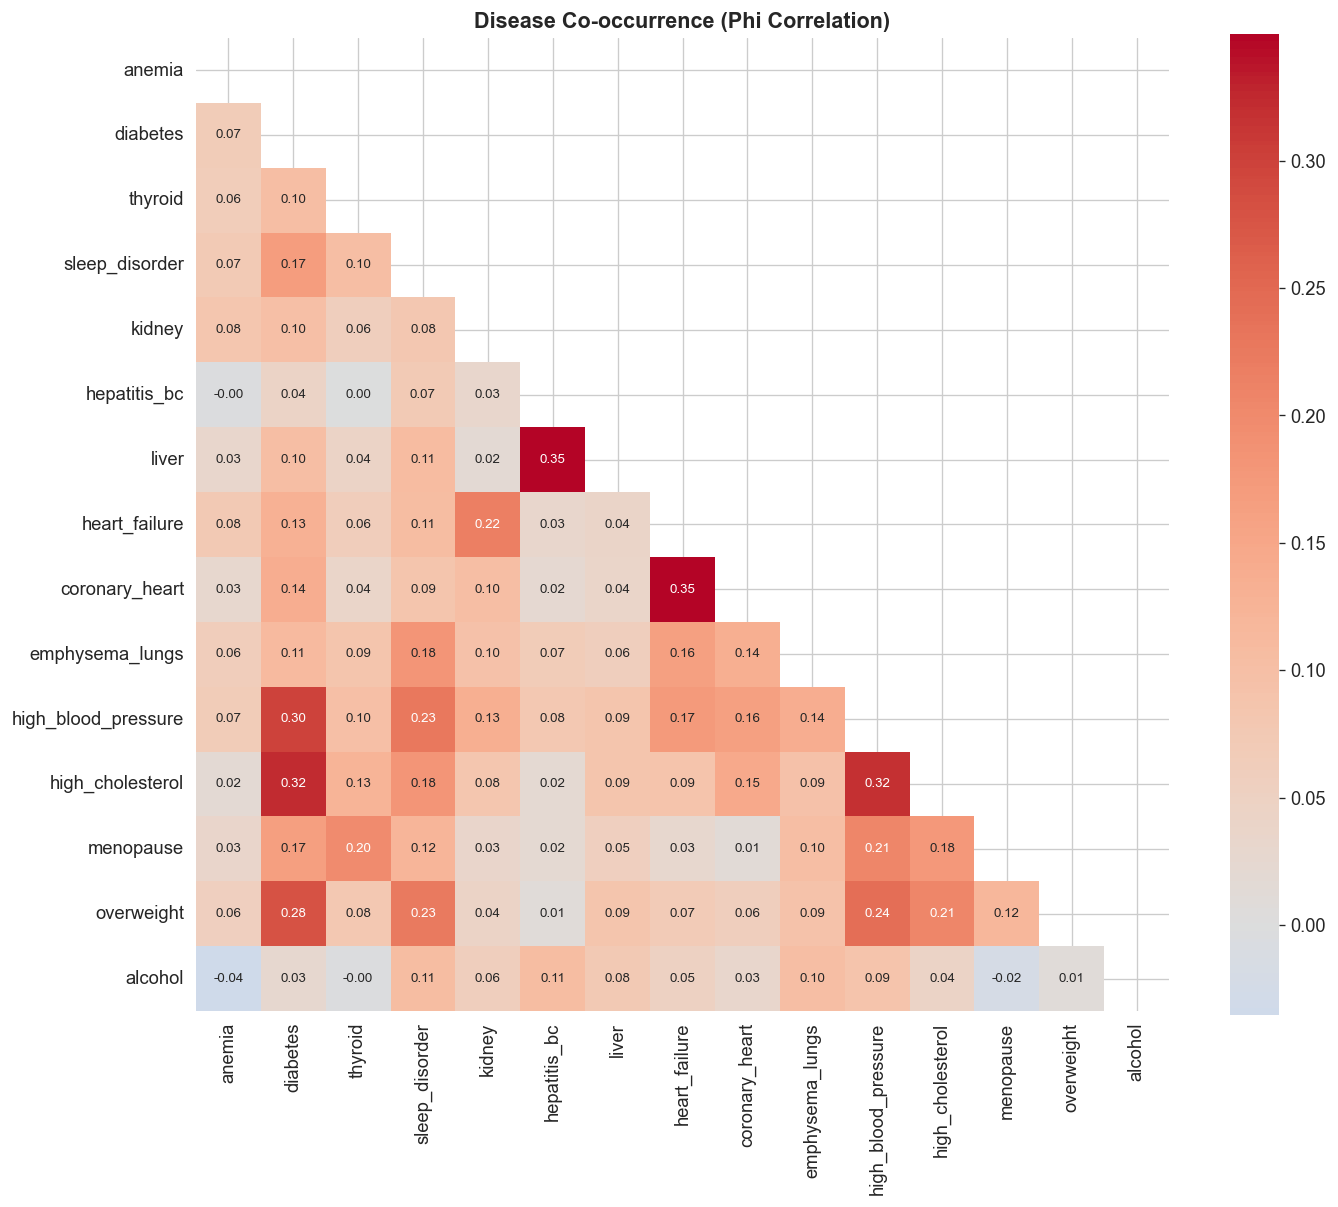

Top 10 disease co-occurrences:
coronary_heart       heart_failure          0.349844
hepatitis_bc         liver                  0.348820
diabetes             high_cholesterol       0.321716
high_blood_pressure  high_cholesterol       0.317628
diabetes             high_blood_pressure    0.299447
                     overweight             0.279338
high_blood_pressure  overweight             0.240526
                     sleep_disorder         0.227655
overweight           sleep_disorder         0.225881
heart_failure        kidney                 0.216767
dtype: float64


In [7]:
# Disease co-occurrence heatmap
disease_corr = df[DISEASE_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(disease_corr, dtype=bool))
sns.heatmap(disease_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, annot_kws={'size':8})
ax.set_title('Disease Co-occurrence (Phi Correlation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top co-occurrences
corr_pairs = disease_corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
print('Top 10 disease co-occurrences:')
print(corr_pairs.abs().sort_values(ascending=False).head(10))

---
## 4. DPQ040 vs Demographics

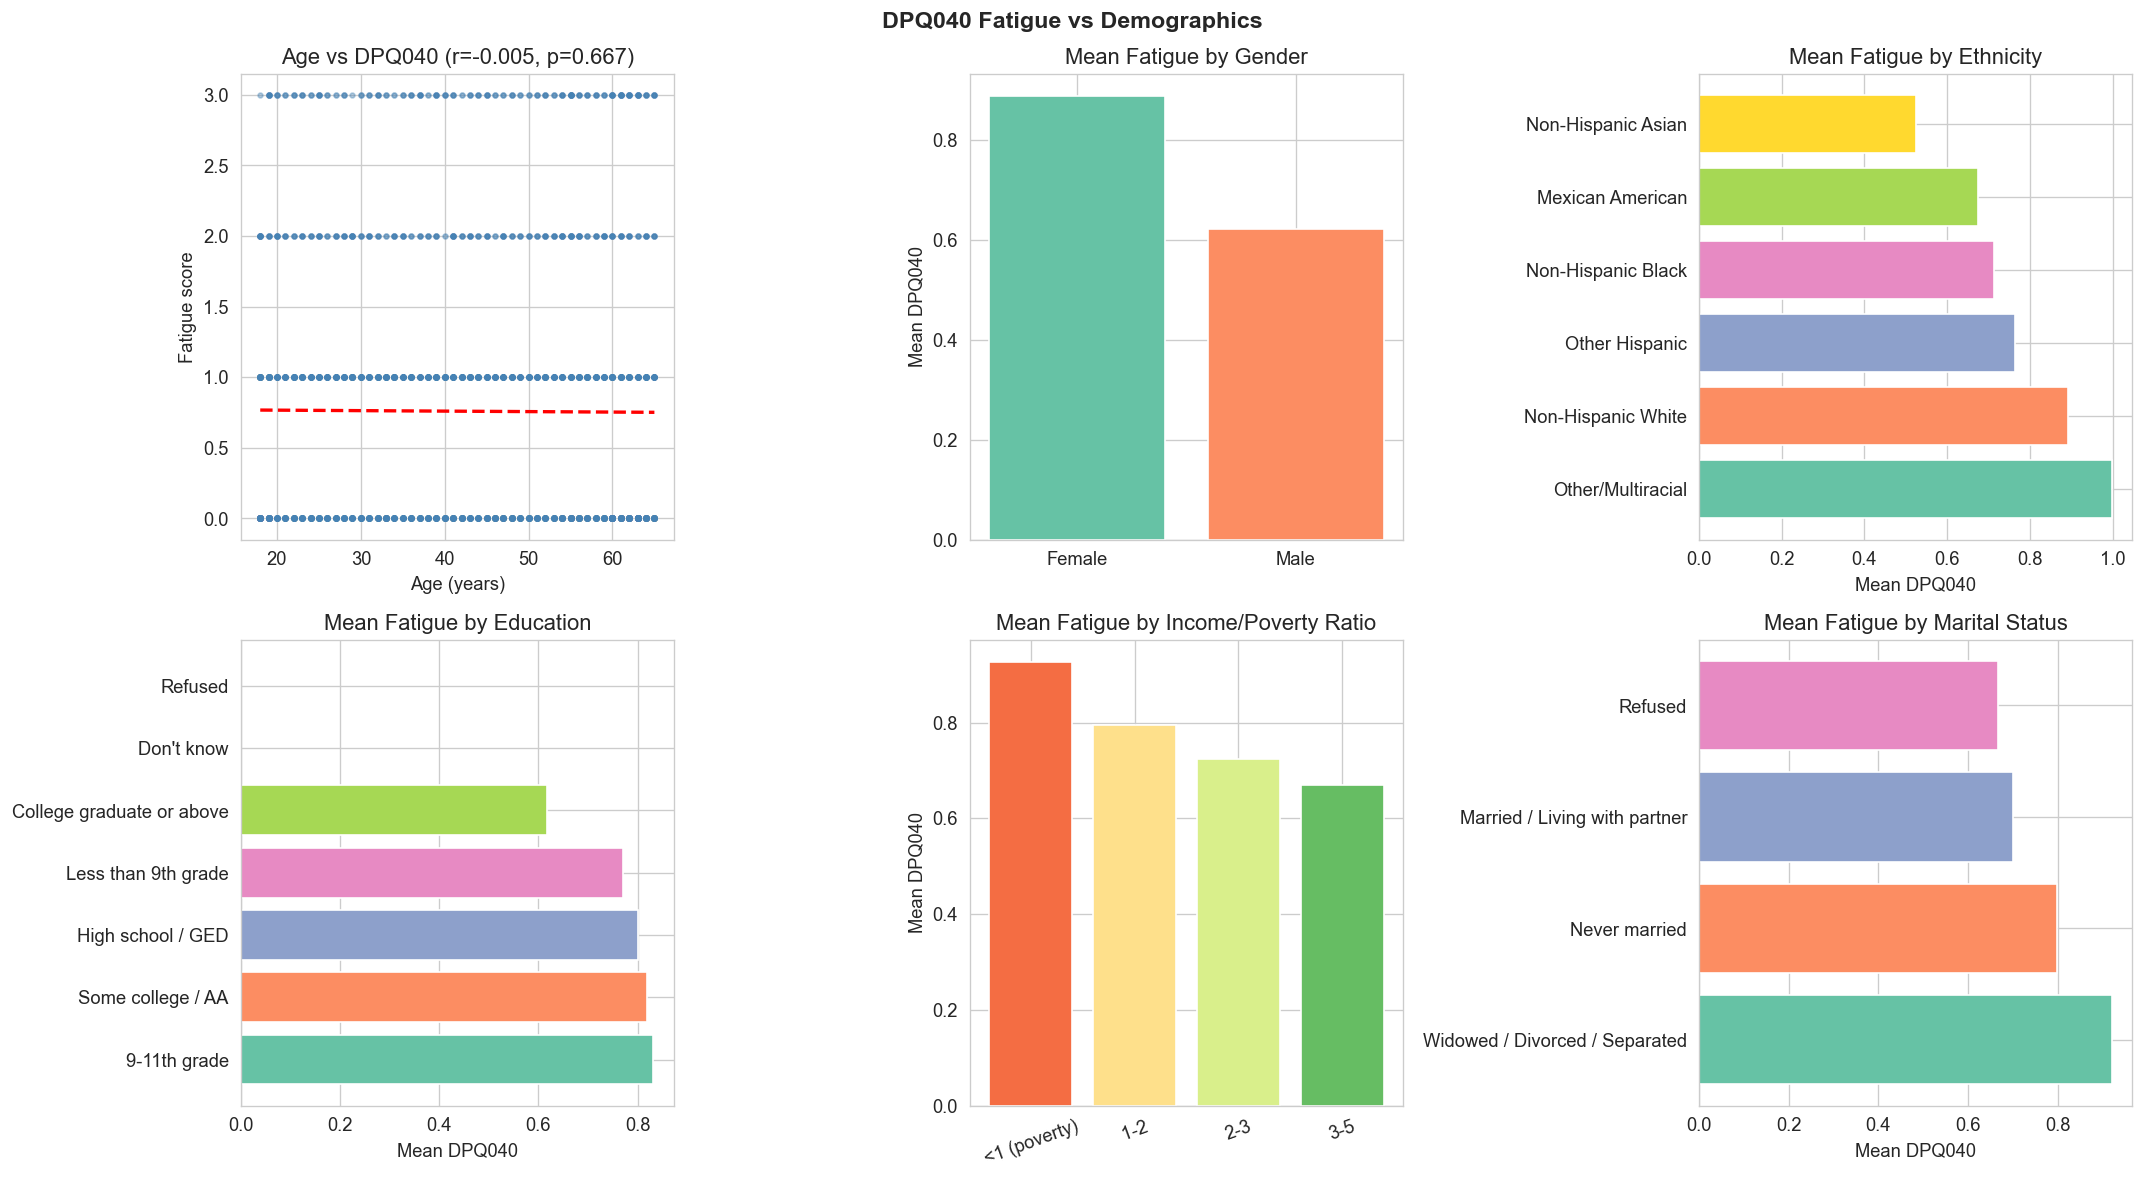


> Expert notes:
  - Age: mild positive correlation expected (older = more fatigue)
  - Gender: women typically report higher fatigue (hormonal cycles, anemia risk)
  - Poverty: strong socioeconomic gradient — lower income → higher fatigue
  - Education: proxy for SES — likely inverse relationship with fatigue


In [8]:
df_dpq = df[df[TARGET].notna()].copy()
df_dpq[TARGET] = df_dpq[TARGET].astype(float)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age
axes[0,0].scatter(df_dpq['age_years'], df_dpq[TARGET], alpha=0.15, s=8, color='steelblue')
z = np.polyfit(df_dpq['age_years'].dropna(), df_dpq.loc[df_dpq['age_years'].notna(), TARGET], 1)
x_line = np.linspace(df_dpq['age_years'].min(), df_dpq['age_years'].max(), 100)
axes[0,0].plot(x_line, np.polyval(z, x_line), 'r--', lw=2)
r, p = stats.pearsonr(df_dpq['age_years'].dropna(),
                       df_dpq.loc[df_dpq['age_years'].notna(), TARGET])
axes[0,0].set_title(f'Age vs DPQ040 (r={r:.3f}, p={p:.3f})')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Fatigue score')

# Gender
gender_dpq = df_dpq.groupby('gender')[TARGET].mean().sort_values(ascending=False)
axes[0,1].bar(gender_dpq.index, gender_dpq.values, color=sns.color_palette(PALETTE,2))
axes[0,1].set_title('Mean Fatigue by Gender')
axes[0,1].set_ylabel('Mean DPQ040')

# Ethnicity
eth_dpq = df_dpq.groupby('ethnicity')[TARGET].mean().sort_values(ascending=False)
axes[0,2].barh(eth_dpq.index, eth_dpq.values, color=sns.color_palette(PALETTE, len(eth_dpq)))
axes[0,2].set_title('Mean Fatigue by Ethnicity')
axes[0,2].set_xlabel('Mean DPQ040')

# Education
edu_dpq = df_dpq.groupby('education')[TARGET].mean().sort_values(ascending=False)
axes[1,0].barh(edu_dpq.index, edu_dpq.values, color=sns.color_palette(PALETTE, len(edu_dpq)))
axes[1,0].set_title('Mean Fatigue by Education')
axes[1,0].set_xlabel('Mean DPQ040')

# Income poverty ratio
df_dpq['income_bucket'] = pd.cut(df_dpq['income_poverty_ratio'], bins=[0,1,2,3,5,20],
                                   labels=['<1 (poverty)','1-2','2-3','3-5','>5'])
inc_dpq = df_dpq.groupby('income_bucket')[TARGET].mean()
axes[1,1].bar(inc_dpq.index.astype(str), inc_dpq.values,
              color=sns.color_palette('RdYlGn', len(inc_dpq)))
axes[1,1].set_title('Mean Fatigue by Income/Poverty Ratio')
axes[1,1].set_ylabel('Mean DPQ040')
axes[1,1].tick_params(axis='x', rotation=20)

# Marital status
mar_dpq = df_dpq.groupby('marital_status')[TARGET].mean().sort_values(ascending=False)
axes[1,2].barh(mar_dpq.index, mar_dpq.values, color=sns.color_palette(PALETTE, len(mar_dpq)))
axes[1,2].set_title('Mean Fatigue by Marital Status')
axes[1,2].set_xlabel('Mean DPQ040')

plt.suptitle('DPQ040 Fatigue vs Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n> Expert notes:')
print('  - Age: mild positive correlation expected (older = more fatigue)')
print('  - Gender: women typically report higher fatigue (hormonal cycles, anemia risk)')
print('  - Poverty: strong socioeconomic gradient — lower income → higher fatigue')
print('  - Education: proxy for SES — likely inverse relationship with fatigue')

---
## 5. DPQ040 vs Each Disease

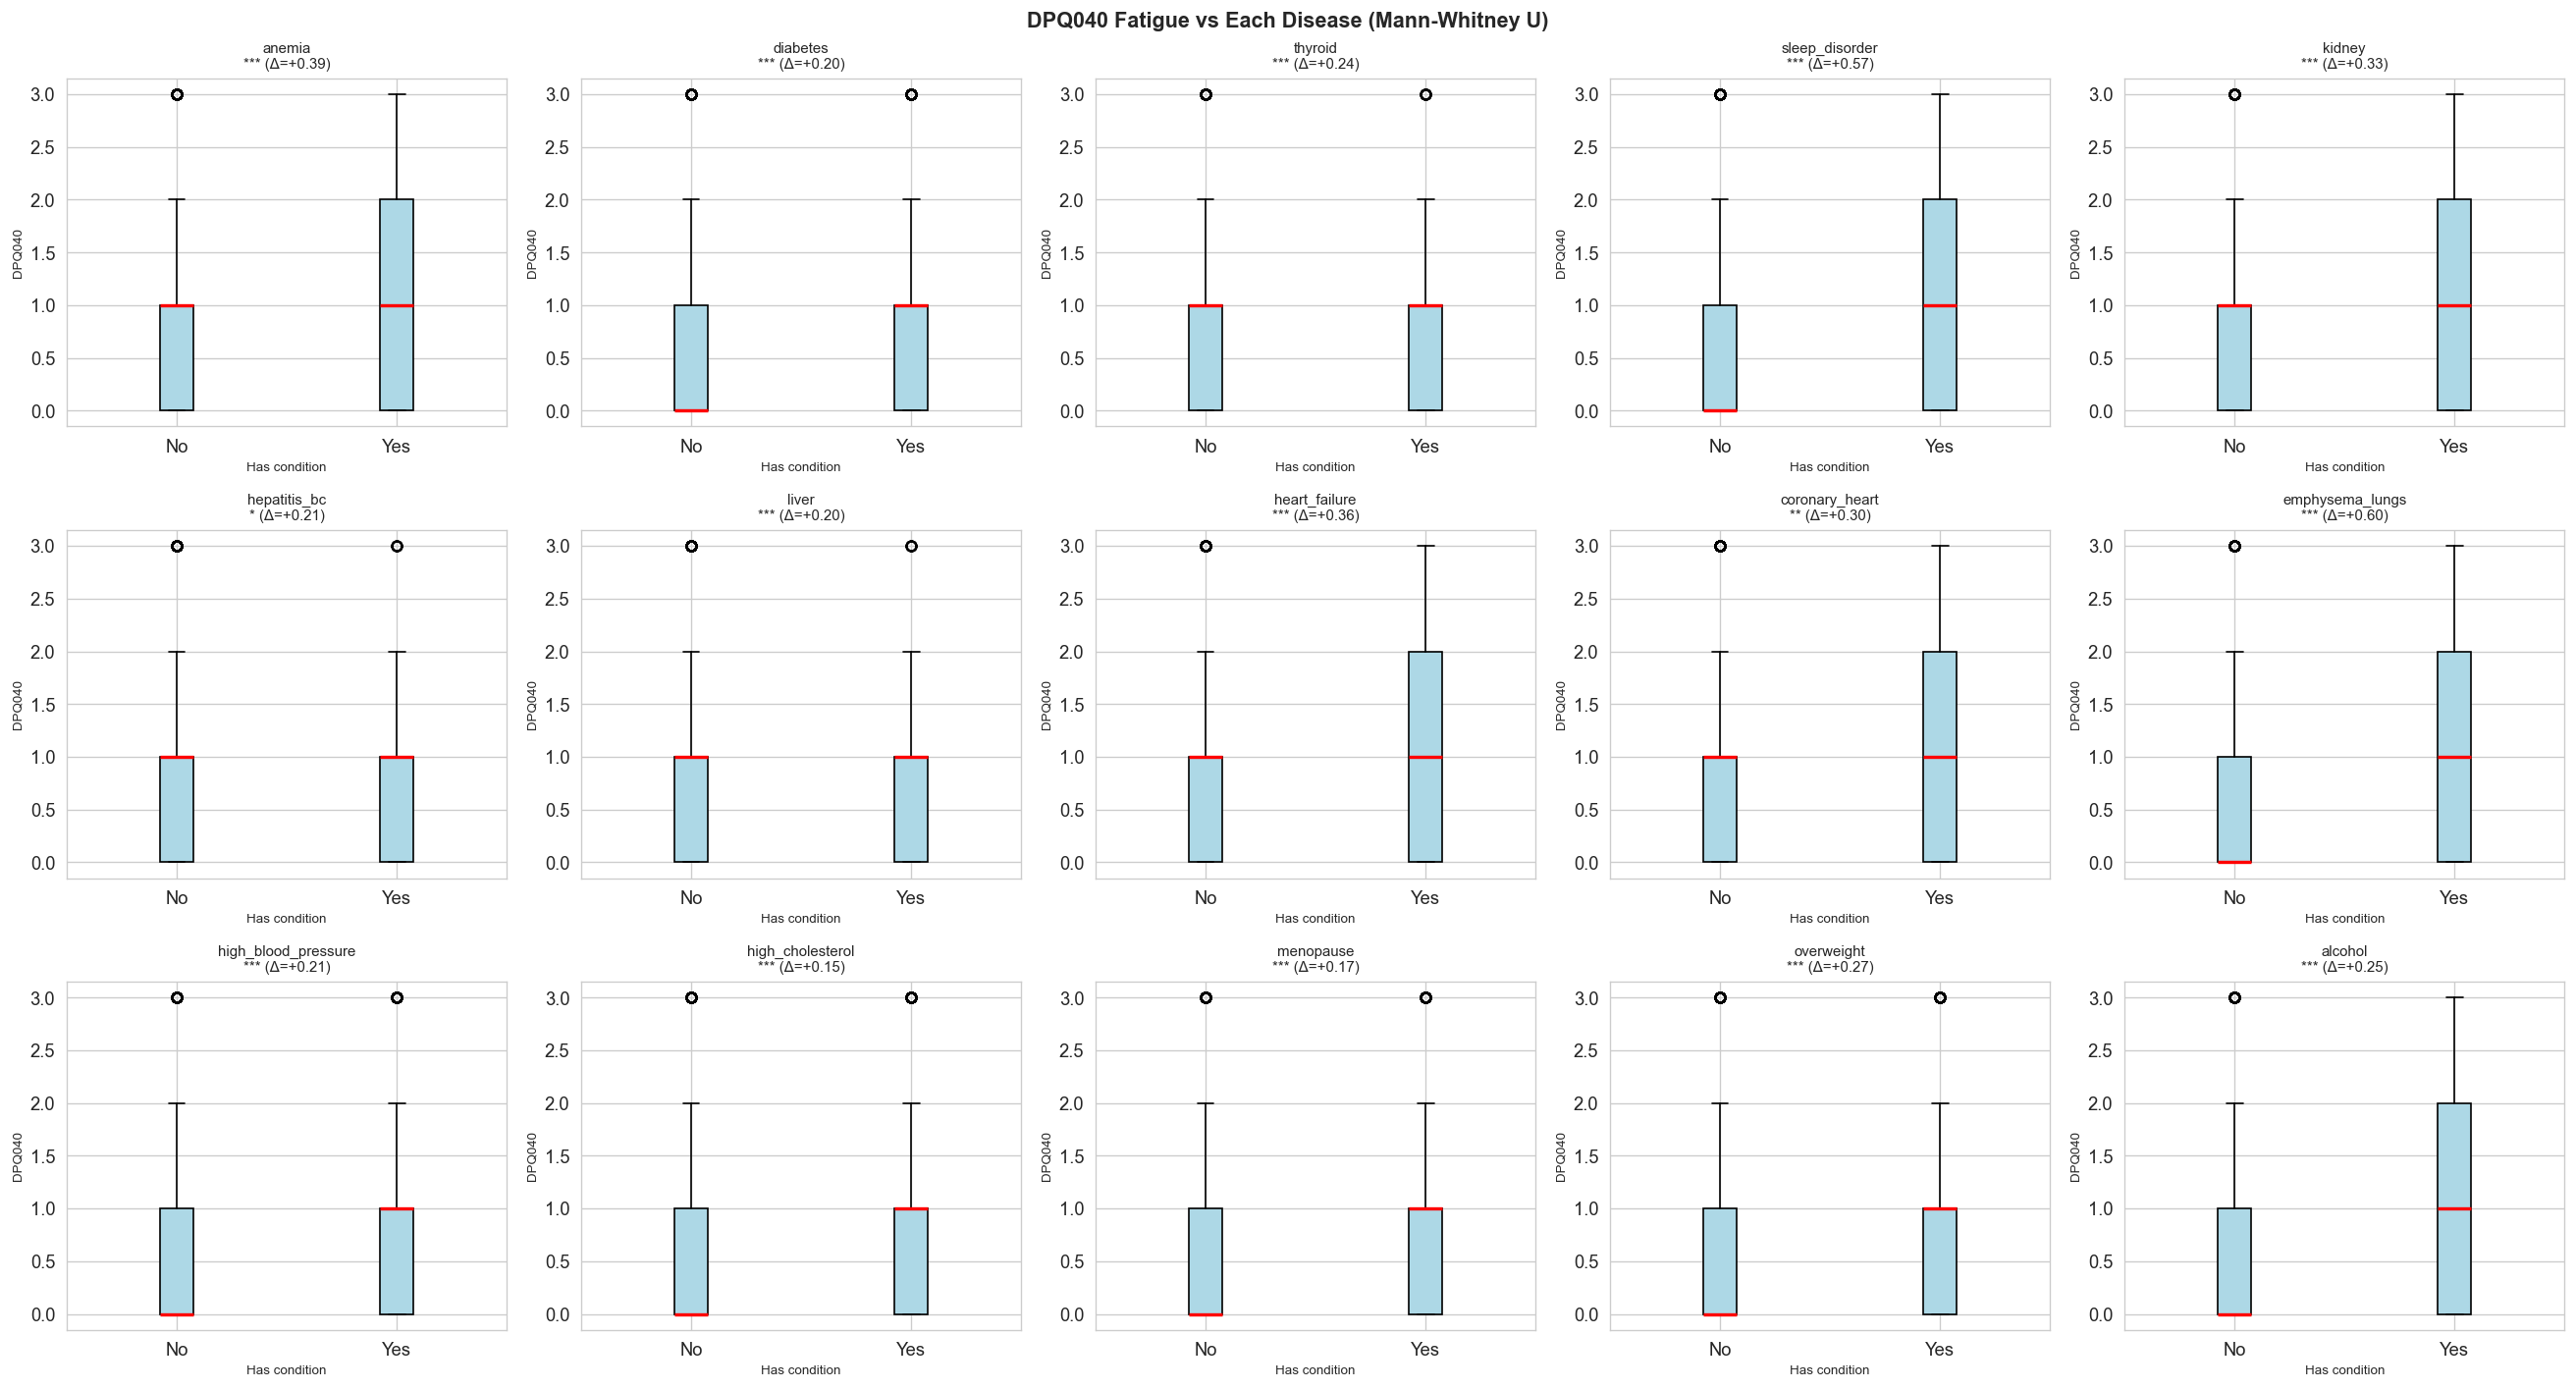

Disease impact on fatigue (sorted by mean difference):
            disease  mean_no  mean_yes  diff  p_value
    emphysema_lungs    0.719     1.321 0.602    0.000
     sleep_disorder    0.571     1.138 0.567    0.000
             anemia    0.741     1.126 0.385    0.000
      heart_failure    0.752     1.111 0.359    0.000
             kidney    0.750     1.081 0.331    0.000
     coronary_heart    0.753     1.055 0.302    0.008
         overweight    0.649     0.924 0.275    0.000
            alcohol    0.726     0.974 0.248    0.000
            thyroid    0.743     0.988 0.244    0.000
high_blood_pressure    0.698     0.908 0.210    0.000
       hepatitis_bc    0.753     0.960 0.207    0.038
           diabetes    0.713     0.914 0.202    0.000
              liver    0.750     0.948 0.197    0.000
          menopause    0.725     0.898 0.173    0.000
   high_cholesterol    0.719     0.866 0.147    0.000


In [9]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

disease_fatigue_stats = []

for i, disease in enumerate(DISEASE_COLS):
    sub = df_dpq[[TARGET, disease]].dropna()
    g0 = sub[sub[disease]==0][TARGET]
    g1 = sub[sub[disease]==1][TARGET]
    
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    effect = (g1.mean() - g0.mean())
    disease_fatigue_stats.append({'disease': disease,
                                   'mean_no': g0.mean(), 'mean_yes': g1.mean(),
                                   'diff': effect, 'p_value': p})
    
    axes[i].boxplot([g0, g1], labels=['No','Yes'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    axes[i].set_title(f'{disease}\n{sig} (Δ={effect:+.2f})', fontsize=9)
    axes[i].set_ylabel('DPQ040', fontsize=8)
    axes[i].set_xlabel('Has condition', fontsize=8)

plt.suptitle('DPQ040 Fatigue vs Each Disease (Mann-Whitney U)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(disease_fatigue_stats).sort_values('diff', ascending=False)
print('Disease impact on fatigue (sorted by mean difference):')
print(stats_df.to_string(index=False, float_format='{:.3f}'.format))

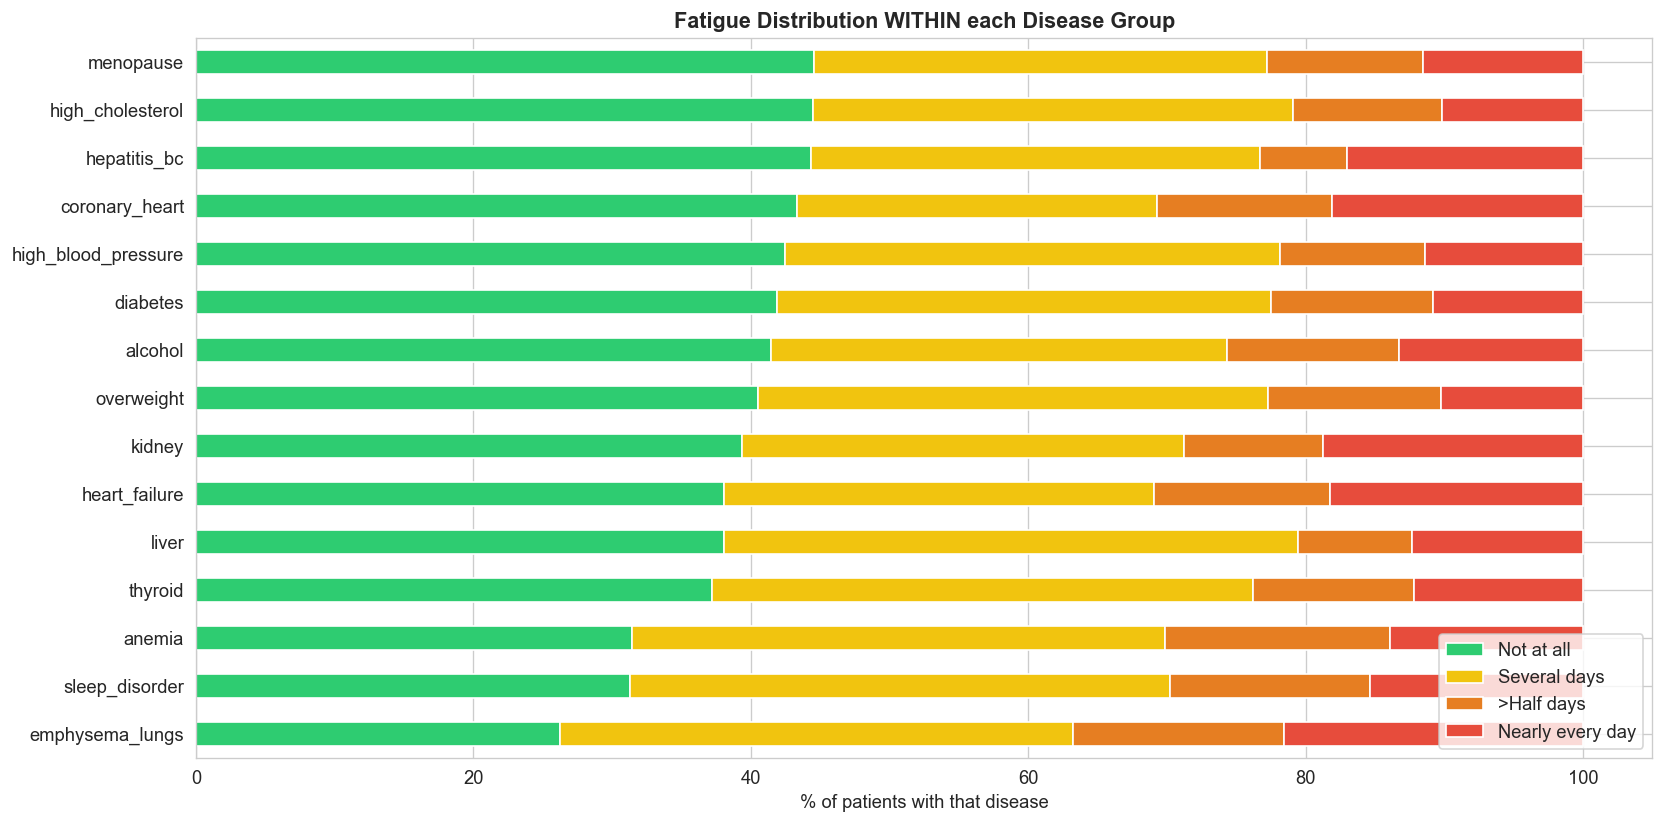

In [10]:
# Stacked bar: fatigue distribution within each disease
fatigue_by_disease = {}
for disease in DISEASE_COLS:
    sub = df_dpq[[TARGET, disease]].dropna()
    pct = sub[sub[disease]==1][TARGET].value_counts(normalize=True).reindex([0,1,2,3], fill_value=0)
    fatigue_by_disease[disease] = pct

fbd_df = pd.DataFrame(fatigue_by_disease).T * 100
fbd_df.columns = ['Not at all','Several days','>Half days','Nearly every day']

fig, ax = plt.subplots(figsize=(14, 7))
fbd_df.sort_values('Not at all').plot(kind='barh', stacked=True, ax=ax,
                                       color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'])
ax.set_title('Fatigue Distribution WITHIN each Disease Group', fontsize=13, fontweight='bold')
ax.set_xlabel('% of patients with that disease')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 6. DPQ040 vs Nutrition & Lifestyle

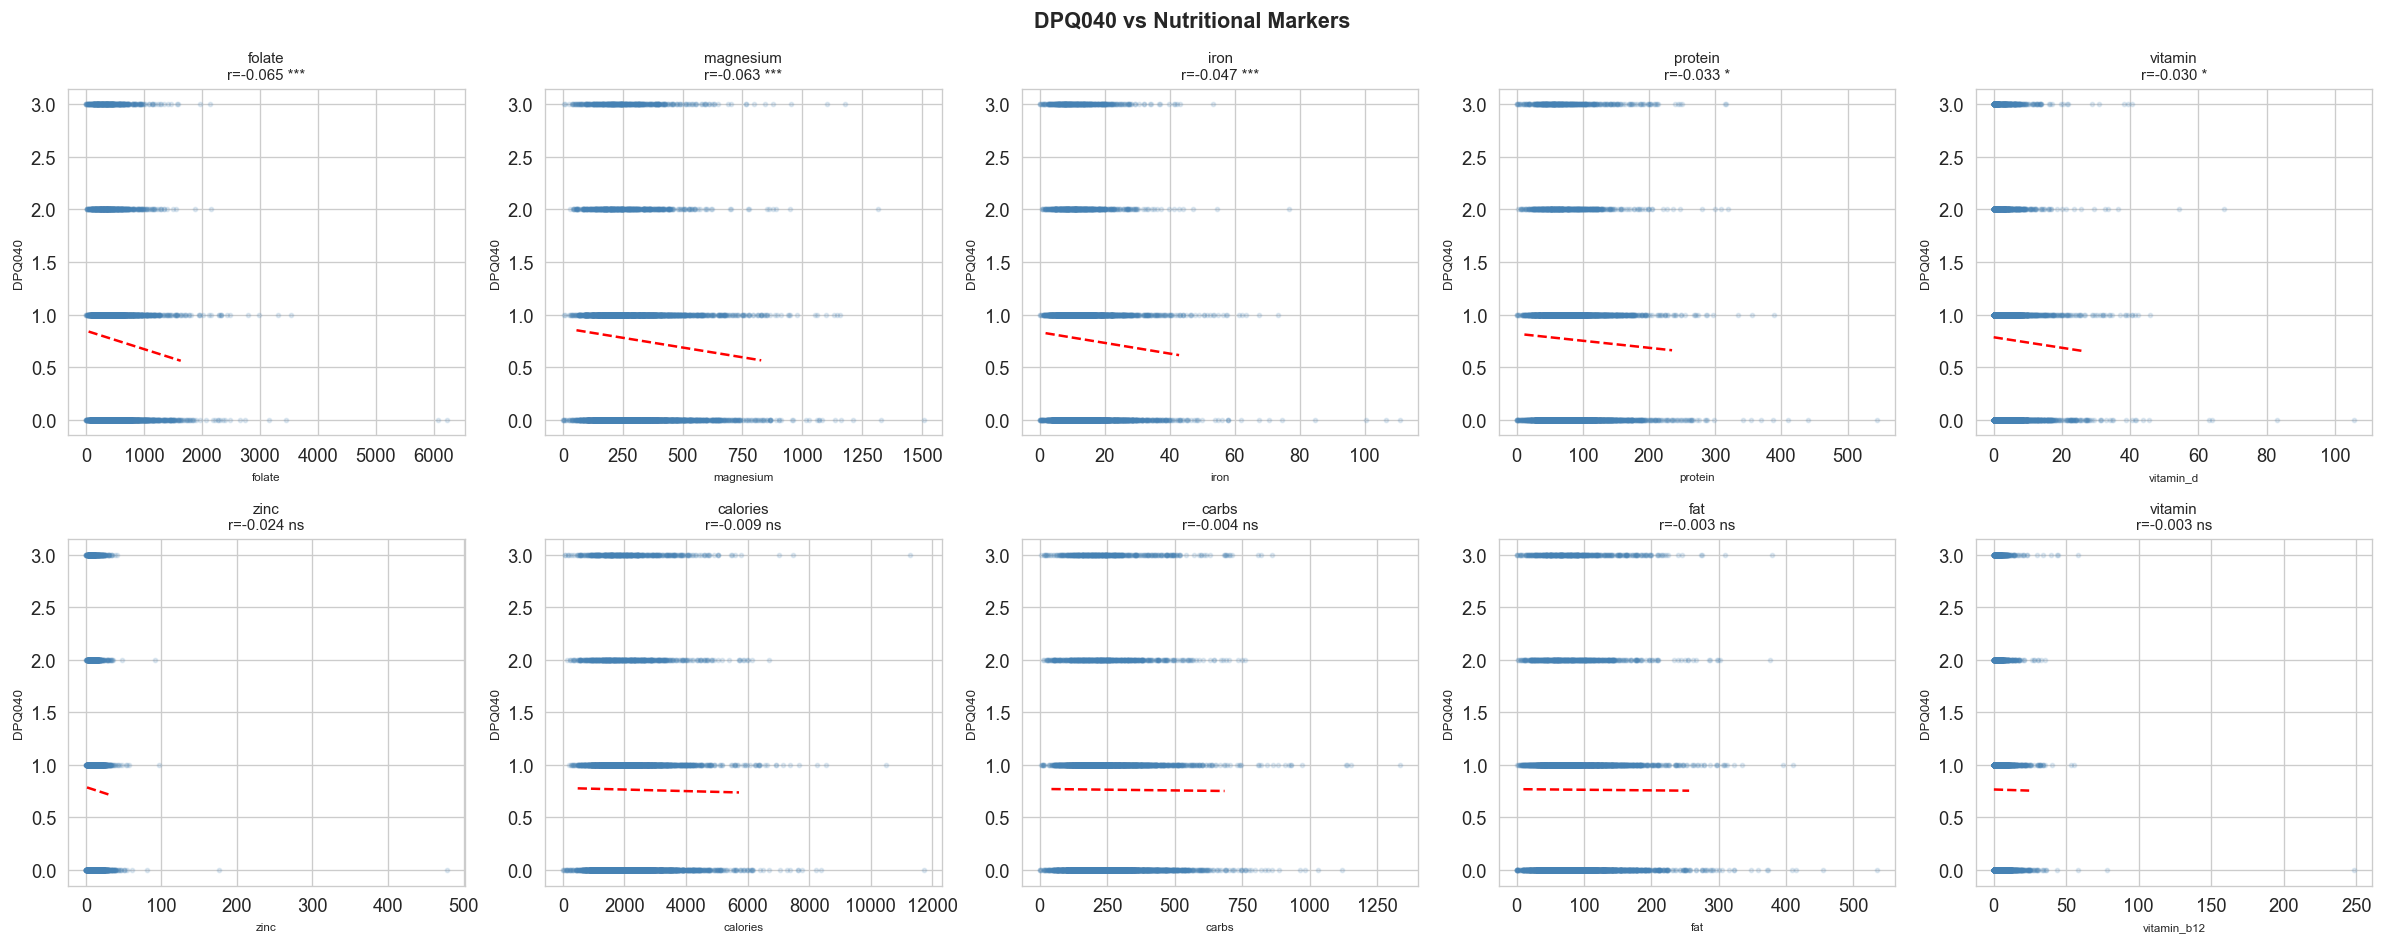

    feature  pearson_r      p_value
     folate  -0.065468 2.881538e-07
  magnesium  -0.062623 9.218214e-07
       iron  -0.046543 2.665170e-04
    protein  -0.032602 1.067660e-02
  vitamin_d  -0.029703 2.001774e-02
       zinc  -0.023544 6.524911e-02
   calories  -0.008538 5.038564e-01
      carbs  -0.004045 7.515074e-01
        fat  -0.003171 8.039560e-01
vitamin_b12  -0.002721 8.313023e-01

> Expert note: Iron and vitamin_b12 deficiency strongly linked to fatigue and anemia.
  Vitamin_d deficiency independently predicts fatigue — potential engineering feature.
  Recommend creating deficiency flags: iron_deficient, vit_d_deficient, vit_b12_deficient.


In [11]:
nutr_corrs = []
for col in NUTRITION_COLS:
    sub = df_dpq[[col, TARGET]].dropna()
    if len(sub) > 50:
        r, p = stats.pearsonr(sub[col], sub[TARGET])
        nutr_corrs.append({'feature': col, 'pearson_r': r, 'p_value': p})

nutr_df = pd.DataFrame(nutr_corrs).sort_values('pearson_r', key=abs, ascending=False)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, row in nutr_df.iterrows():
    sub = df_dpq[[row['feature'], TARGET]].dropna()
    idx = list(nutr_df.index).index(i)
    if idx >= len(axes): break
    axes[idx].scatter(sub[row['feature']], sub[TARGET], alpha=0.15, s=6, color='steelblue')
    z = np.polyfit(sub[row['feature']], sub[TARGET], 1)
    x_line = np.linspace(sub[row['feature']].quantile(0.01), sub[row['feature']].quantile(0.99), 100)
    axes[idx].plot(x_line, np.polyval(z, x_line), 'r--', lw=1.5)
    sig = '***' if row['p_value']<0.001 else '**' if row['p_value']<0.01 else '*' if row['p_value']<0.05 else 'ns'
    axes[idx].set_title(f"{row['feature'].split('_')[0]}\nr={row['pearson_r']:.3f} {sig}", fontsize=9)
    axes[idx].set_xlabel(row['feature'], fontsize=7)
    axes[idx].set_ylabel('DPQ040', fontsize=8)

plt.suptitle('DPQ040 vs Nutritional Markers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(nutr_df.to_string(index=False))
print('\n> Expert note: Iron and vitamin_b12 deficiency strongly linked to fatigue and anemia.')
print('  Vitamin_d deficiency independently predicts fatigue — potential engineering feature.')
print('  Recommend creating deficiency flags: iron_deficient, vit_d_deficient, vit_b12_deficient.')

---
## 7. DPQ040 vs Body Measurements (BMI, BP, etc.)

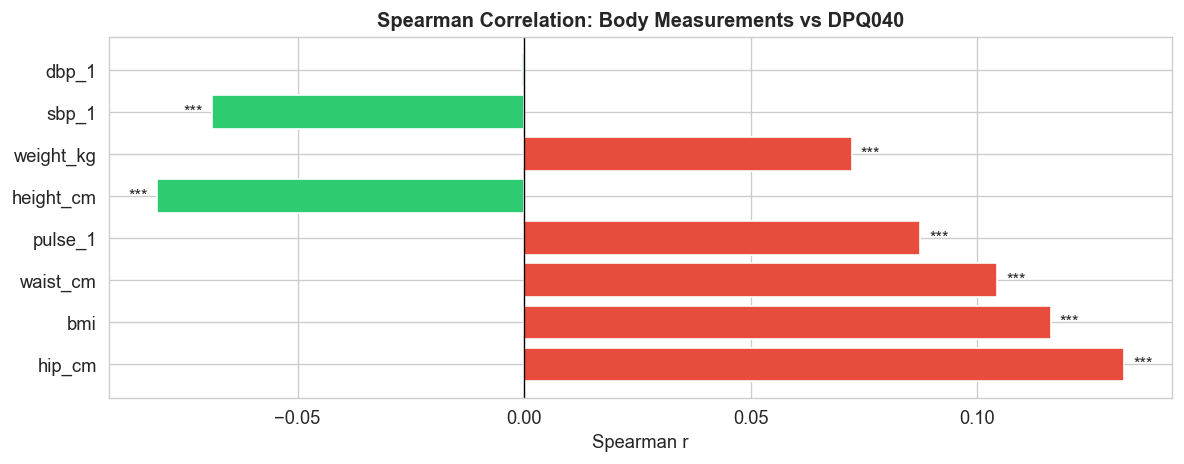

  feature  spearman_r      p_value
   hip_cm    0.132429 5.135391e-26
      bmi    0.116209 1.049835e-20
 waist_cm    0.104447 1.063736e-16
  pulse_1    0.087424 8.429040e-11
height_cm   -0.081008 8.215229e-11
weight_kg    0.072289 6.833033e-09
    sbp_1   -0.068923 9.026679e-08
    dbp_1   -0.000444 9.725822e-01


In [12]:
body_cols = ['bmi','weight_kg','height_cm','waist_cm','hip_cm',
             'sbp_1','dbp_1','pulse_1']
body_cols = [c for c in body_cols if c in df_dpq.columns]

body_corrs = []
for col in body_cols:
    sub = df_dpq[[col, TARGET]].dropna()
    if len(sub) > 50:
        r, p = stats.spearmanr(sub[col], sub[TARGET])
        body_corrs.append({'feature': col, 'spearman_r': r, 'p_value': p})

body_df = pd.DataFrame(body_corrs).sort_values('spearman_r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if r > 0 else '#2ecc71' for r in body_df['spearman_r']]
ax.barh(body_df['feature'], body_df['spearman_r'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Spearman Correlation: Body Measurements vs DPQ040', fontsize=12, fontweight='bold')
ax.set_xlabel('Spearman r')
for i, (r, p) in enumerate(zip(body_df['spearman_r'], body_df['p_value'])):
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    ax.text(r + (0.002 if r >= 0 else -0.002), i, sig, va='center',
            ha='left' if r >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()
print(body_df.to_string(index=False))

---
## 8. DPQ040 vs Sleep Metrics

Numeric sleep cols: ['sld012___sleep_hours___weekdays_or_workdays', 'sld013___sleep_hours___weekends', 'slq030___how_often_do_you_snore?', 'slq040___how_often_do_you_snort_or_stop_breathing', 'slq050___ever_told_doctor_had_trouble_sleeping?', 'sleep_disorder']


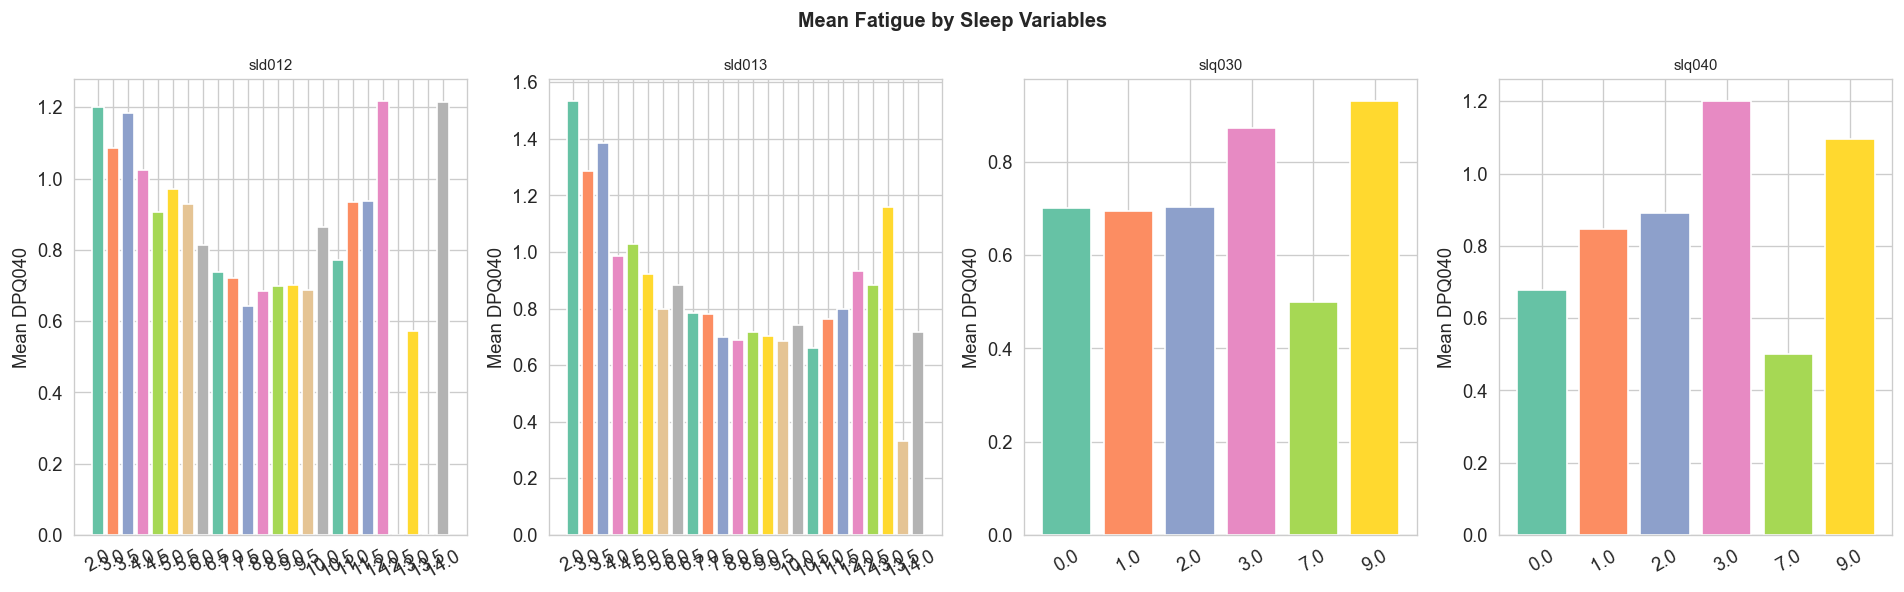


> Expert note: SLQ040 (snorting/stopping breathing) is the key sleep apnea proxy.
  Patients with sleep disorder (score 2-3) expected to show significantly higher fatigue.
  Consider engineering: sleep_hours from SLQ300/SLQ310 wake-time difference.


In [13]:
sleep_cols = [c for c in df_dpq.columns if 'slq' in c.lower() or 'sleep' in c.lower()]
# Keep numeric only
sleep_num = [c for c in sleep_cols if pd.api.types.is_numeric_dtype(df_dpq[c])]
print('Numeric sleep cols:', sleep_num)

fig, axes = plt.subplots(1, min(len(sleep_num),4), figsize=(16, 5))
if len(sleep_num) == 1:
    axes = [axes]
for ax, col in zip(axes, sleep_num[:4]):
    sub = df_dpq[[col, TARGET]].dropna()
    sub[col] = pd.to_numeric(sub[col], errors='coerce')
    sub = sub.dropna()
    if len(sub) < 30:
        continue
    means = sub.groupby(col)[TARGET].mean()
    ax.bar(means.index.astype(str), means.values, color=sns.color_palette(PALETTE, len(means)))
    ax.set_title(col.split('___')[0], fontsize=9)
    ax.set_ylabel('Mean DPQ040')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Mean Fatigue by Sleep Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n> Expert note: SLQ040 (snorting/stopping breathing) is the key sleep apnea proxy.')
print('  Patients with sleep disorder (score 2-3) expected to show significantly higher fatigue.')
print('  Consider engineering: sleep_hours from SLQ300/SLQ310 wake-time difference.')

---
## 9. Feature Importance for DPQ040 (Random Forest)

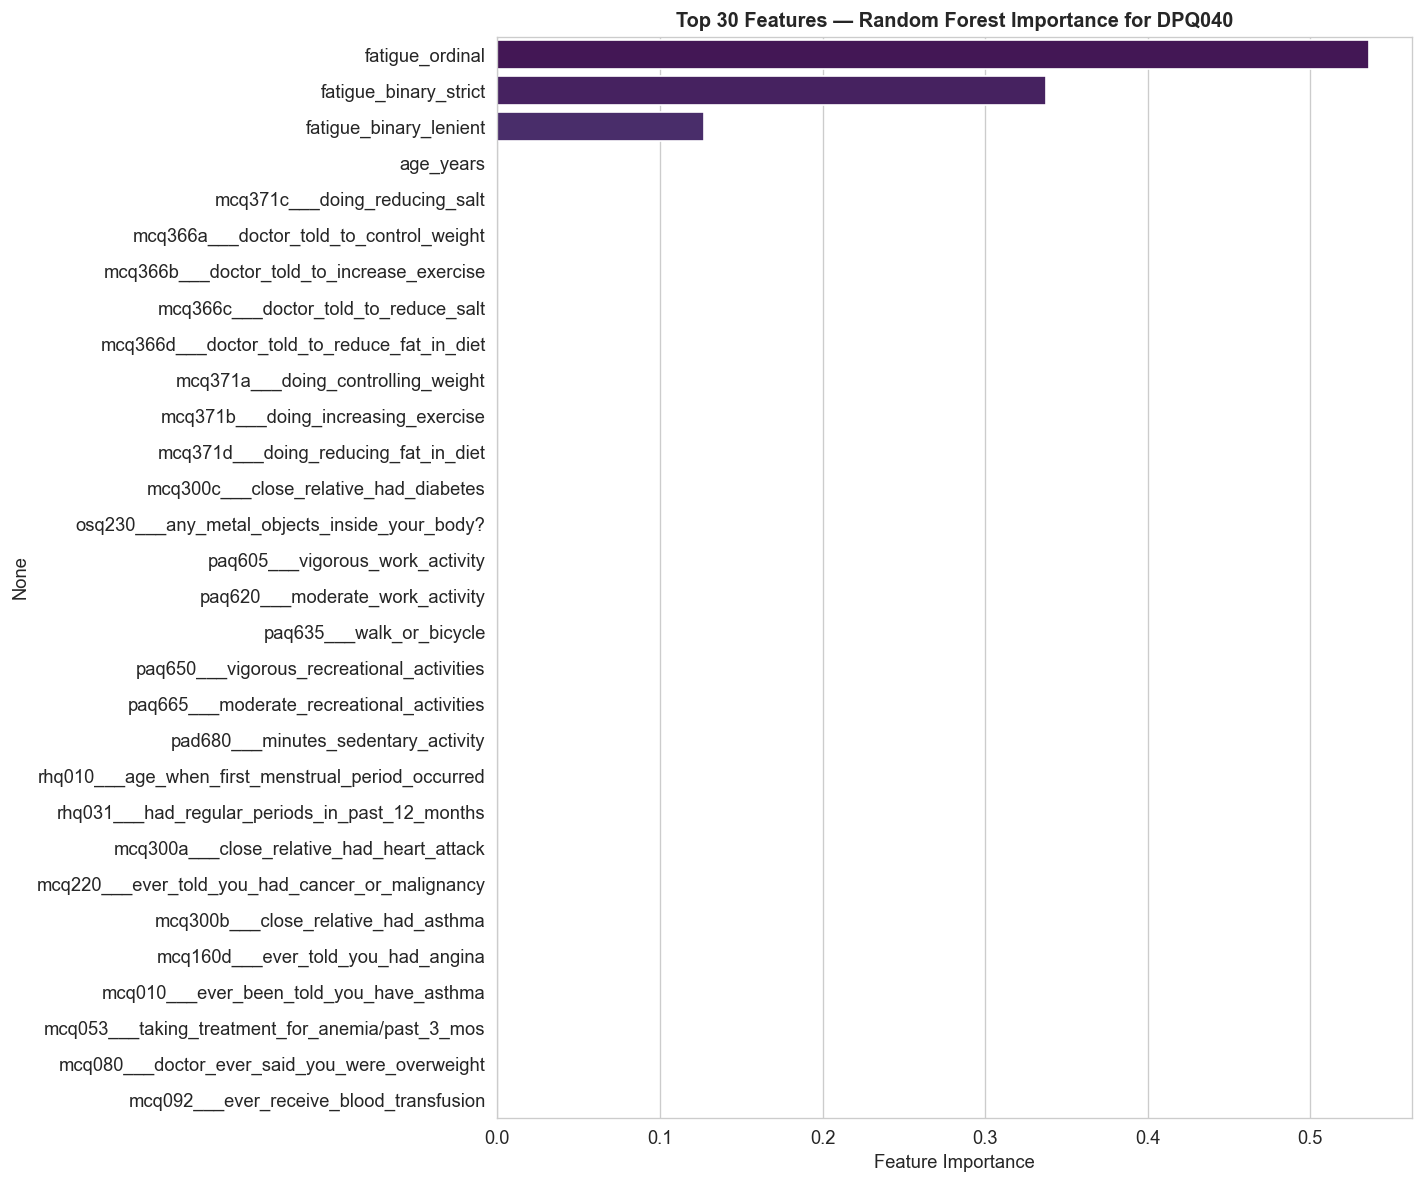

Top 30 features for fatigue prediction:
fatigue_ordinal                                      0.535967
fatigue_binary_strict                                0.337208
fatigue_binary_lenient                               0.126825
age_years                                            0.000000
mcq371c___doing_reducing_salt                        0.000000
mcq366a___doctor_told_to_control_weight              0.000000
mcq366b___doctor_told_to_increase_exercise           0.000000
mcq366c___doctor_told_to_reduce_salt                 0.000000
mcq366d___doctor_told_to_reduce_fat_in_diet          0.000000
mcq371a___doing_controlling_weight                   0.000000
mcq371b___doing_increasing_exercise                  0.000000
mcq371d___doing_reducing_fat_in_diet                 0.000000
mcq300c___close_relative_had_diabetes                0.000000
osq230___any_metal_objects_inside_your_body?         0.000000
paq605___vigorous_work_activity                      0.000000
paq620___moderate_work_activit

In [14]:
# Use questionnaire-type features + diseases + demographics (exclude lab for now — too many NaNs)
exclude = ['SEQN', TARGET] + LAB_COLS
feature_cols = [c for c in df_dpq.select_dtypes(include='number').columns
                if c not in exclude and df_dpq[c].notna().sum() > len(df_dpq)*0.5]

X = df_dpq[feature_cols].copy()
y = df_dpq[TARGET].copy()

# Impute median for remaining NaNs
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_imp, y)

feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top30 = feat_imp.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
sns.barplot(x=top30.values, y=top30.index, palette='viridis', ax=ax)
ax.set_title('Top 30 Features — Random Forest Importance for DPQ040', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print('Top 30 features for fatigue prediction:')
print(top30.to_string())

---
## 10. Lab Markers vs DPQ040 — Top Correlations

Lab cols with >500 non-null values: 466


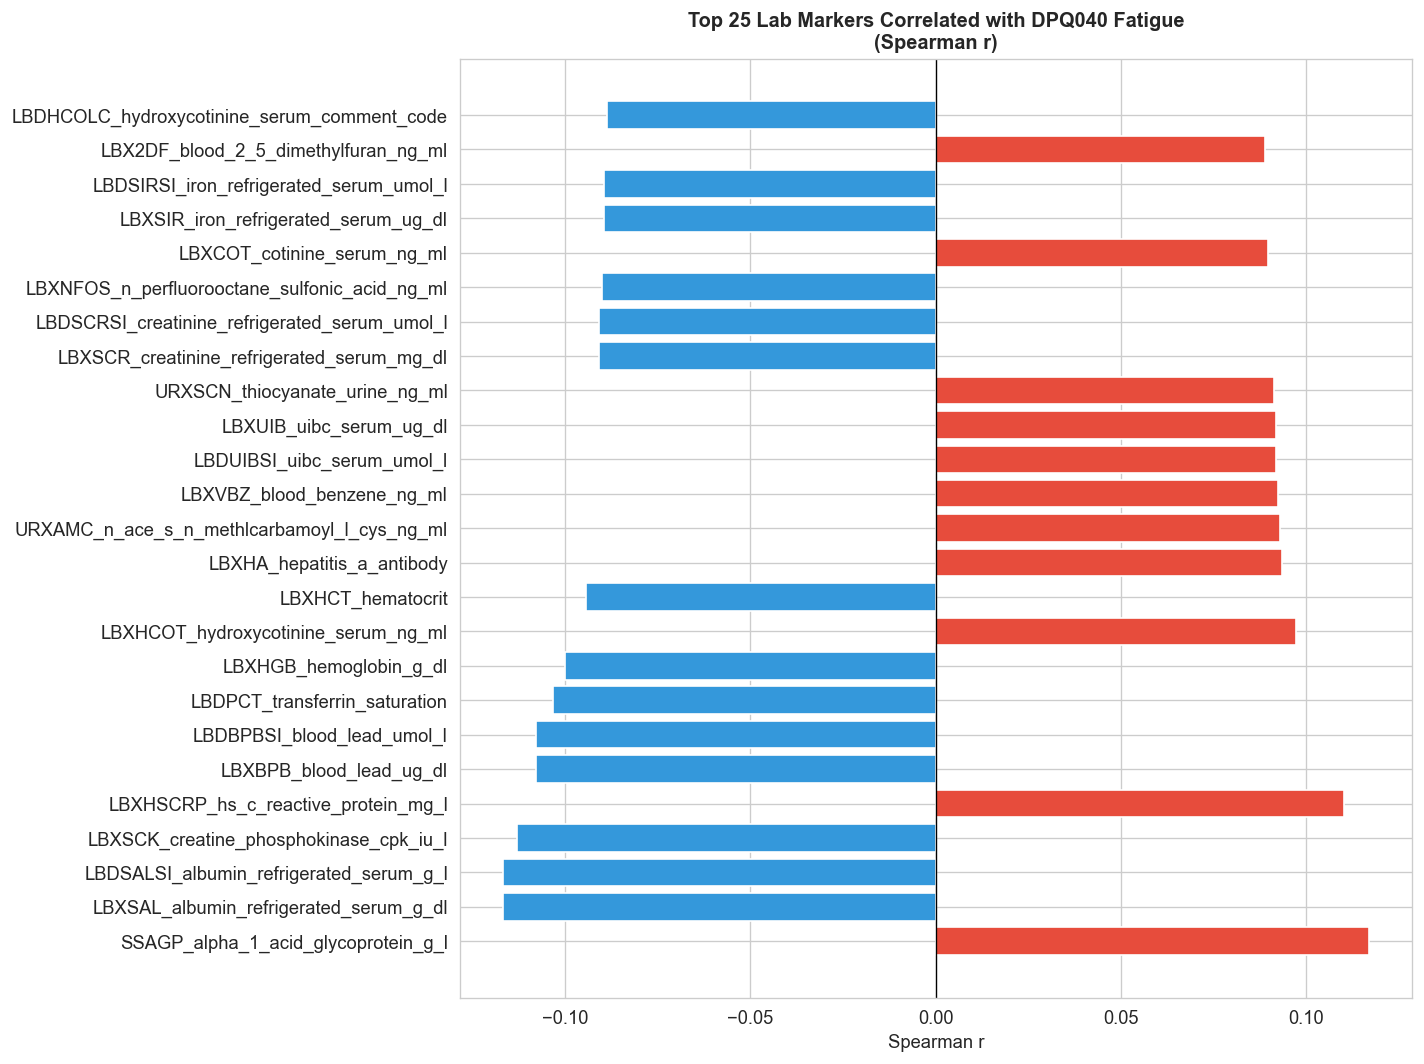

                                          lab  spearman_r      p_value    n
          SSAGP_alpha_1_acid_glycoprotein_g_l    0.117005 1.540833e-06 1678
       LBXSAL_albumin_refrigerated_serum_g_dl   -0.116759 1.115354e-19 6005
      LBDSALSI_albumin_refrigerated_serum_g_l   -0.116759 1.115354e-19 6005
       LBXSCK_creatine_phosphokinase_cpk_iu_l   -0.112976 1.673595e-18 6000
          LBXHSCRP_hs_c_reactive_protein_mg_l    0.110116 1.236362e-17 5994
                      LBXBPB_blood_lead_ug_dl   -0.107831 2.292005e-17 6148
                   LBDBPBSI_blood_lead_umol_l   -0.107719 2.473174e-17 6148
                LBDPCT_transferrin_saturation   -0.103377 1.092445e-15 5983
                       LBXHGB_hemoglobin_g_dl   -0.100138 3.186684e-15 6169
          LBXHCOT_hydroxycotinine_serum_ng_ml    0.097375 3.140761e-14 6053
                            LBXHCT_hematocrit   -0.094480 1.038529e-13 6169
                   LBXHA_hepatitis_a_antibody    0.093480 4.025261e-13 5999
  URXAMC_n_a

In [15]:
# Filter lab cols with enough non-null data
lab_usable = [c for c in LAB_COLS if df_dpq[c].notna().sum() > 500
              and pd.api.types.is_numeric_dtype(df_dpq[c])]
print(f'Lab cols with >500 non-null values: {len(lab_usable)}')

lab_dpq_corrs = []
for col in lab_usable:
    sub = df_dpq[[col, TARGET]].dropna()
    if len(sub) < 100:
        continue
    r, p = stats.spearmanr(sub[col], sub[TARGET])
    lab_dpq_corrs.append({'lab': col, 'spearman_r': r, 'p_value': p, 'n': len(sub)})

lab_dpq_df = pd.DataFrame(lab_dpq_corrs)
lab_dpq_df['abs_r'] = lab_dpq_df['spearman_r'].abs()
lab_dpq_df = lab_dpq_df.sort_values('abs_r', ascending=False)

top_lab = lab_dpq_df.head(25)

fig, ax = plt.subplots(figsize=(12, 9))
colors = ['#e74c3c' if r > 0 else '#3498db' for r in top_lab['spearman_r']]
ax.barh(top_lab['lab'], top_lab['spearman_r'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 25 Lab Markers Correlated with DPQ040 Fatigue\n(Spearman r)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Spearman r')
plt.tight_layout()
plt.show()

print(top_lab[['lab','spearman_r','p_value','n']].to_string(index=False))

---
## 11. Lab Markers vs Each Disease — Feature Importance

In [16]:
# For each disease: find top lab markers using Random Forest
lab_disease_results = {}

# Only use lab cols with enough coverage
lab_model_cols = [c for c in LAB_COLS
                  if pd.api.types.is_numeric_dtype(df[c])
                  and df[c].notna().sum() > 1000]
print(f'Lab cols used for disease models: {len(lab_model_cols)}')

for disease in DISEASE_COLS:
    sub = df[lab_model_cols + [disease]].dropna(subset=[disease])
    y_d = sub[disease]
    if y_d.sum() < 30:
        print(f'  Skipping {disease} — too few positives ({int(y_d.sum())})')
        continue
    X_d = sub[lab_model_cols].copy()
    imp_d = SimpleImputer(strategy='median')
    X_d_imp = imp_d.fit_transform(X_d)
    rf_d = RandomForestClassifier(n_estimators=100, max_depth=6,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    rf_d.fit(X_d_imp, y_d)
    imp_series = pd.Series(rf_d.feature_importances_, index=lab_model_cols).sort_values(ascending=False)
    lab_disease_results[disease] = imp_series
    print(f'  {disease}: top lab = {imp_series.index[0]}')

print('\nDone.')

Lab cols used for disease models: 463


  anemia: top lab = LBXHCT_hematocrit


  diabetes: top lab = LBXGH_glycohemoglobin


  thyroid: top lab = LBXFSH_follicle_stimulating_hormone_miu_ml


  sleep_disorder: top lab = LBXHSCRP_hs_c_reactive_protein_mg_l


...

  high_blood_pressure: top lab = LBXGH_glycohemoglobin


  high_cholesterol: top lab = LBXGH_glycohemoglobin


  menopause: top lab = LBDAMHSI_anti_mullerian_hormone_pmol_l


  overweight: top lab = LBXHSCRP_hs_c_reactive_protein_mg_l


  alcohol: top lab = LBXHCOT_hydroxycotinine_serum_ng_ml

Done.


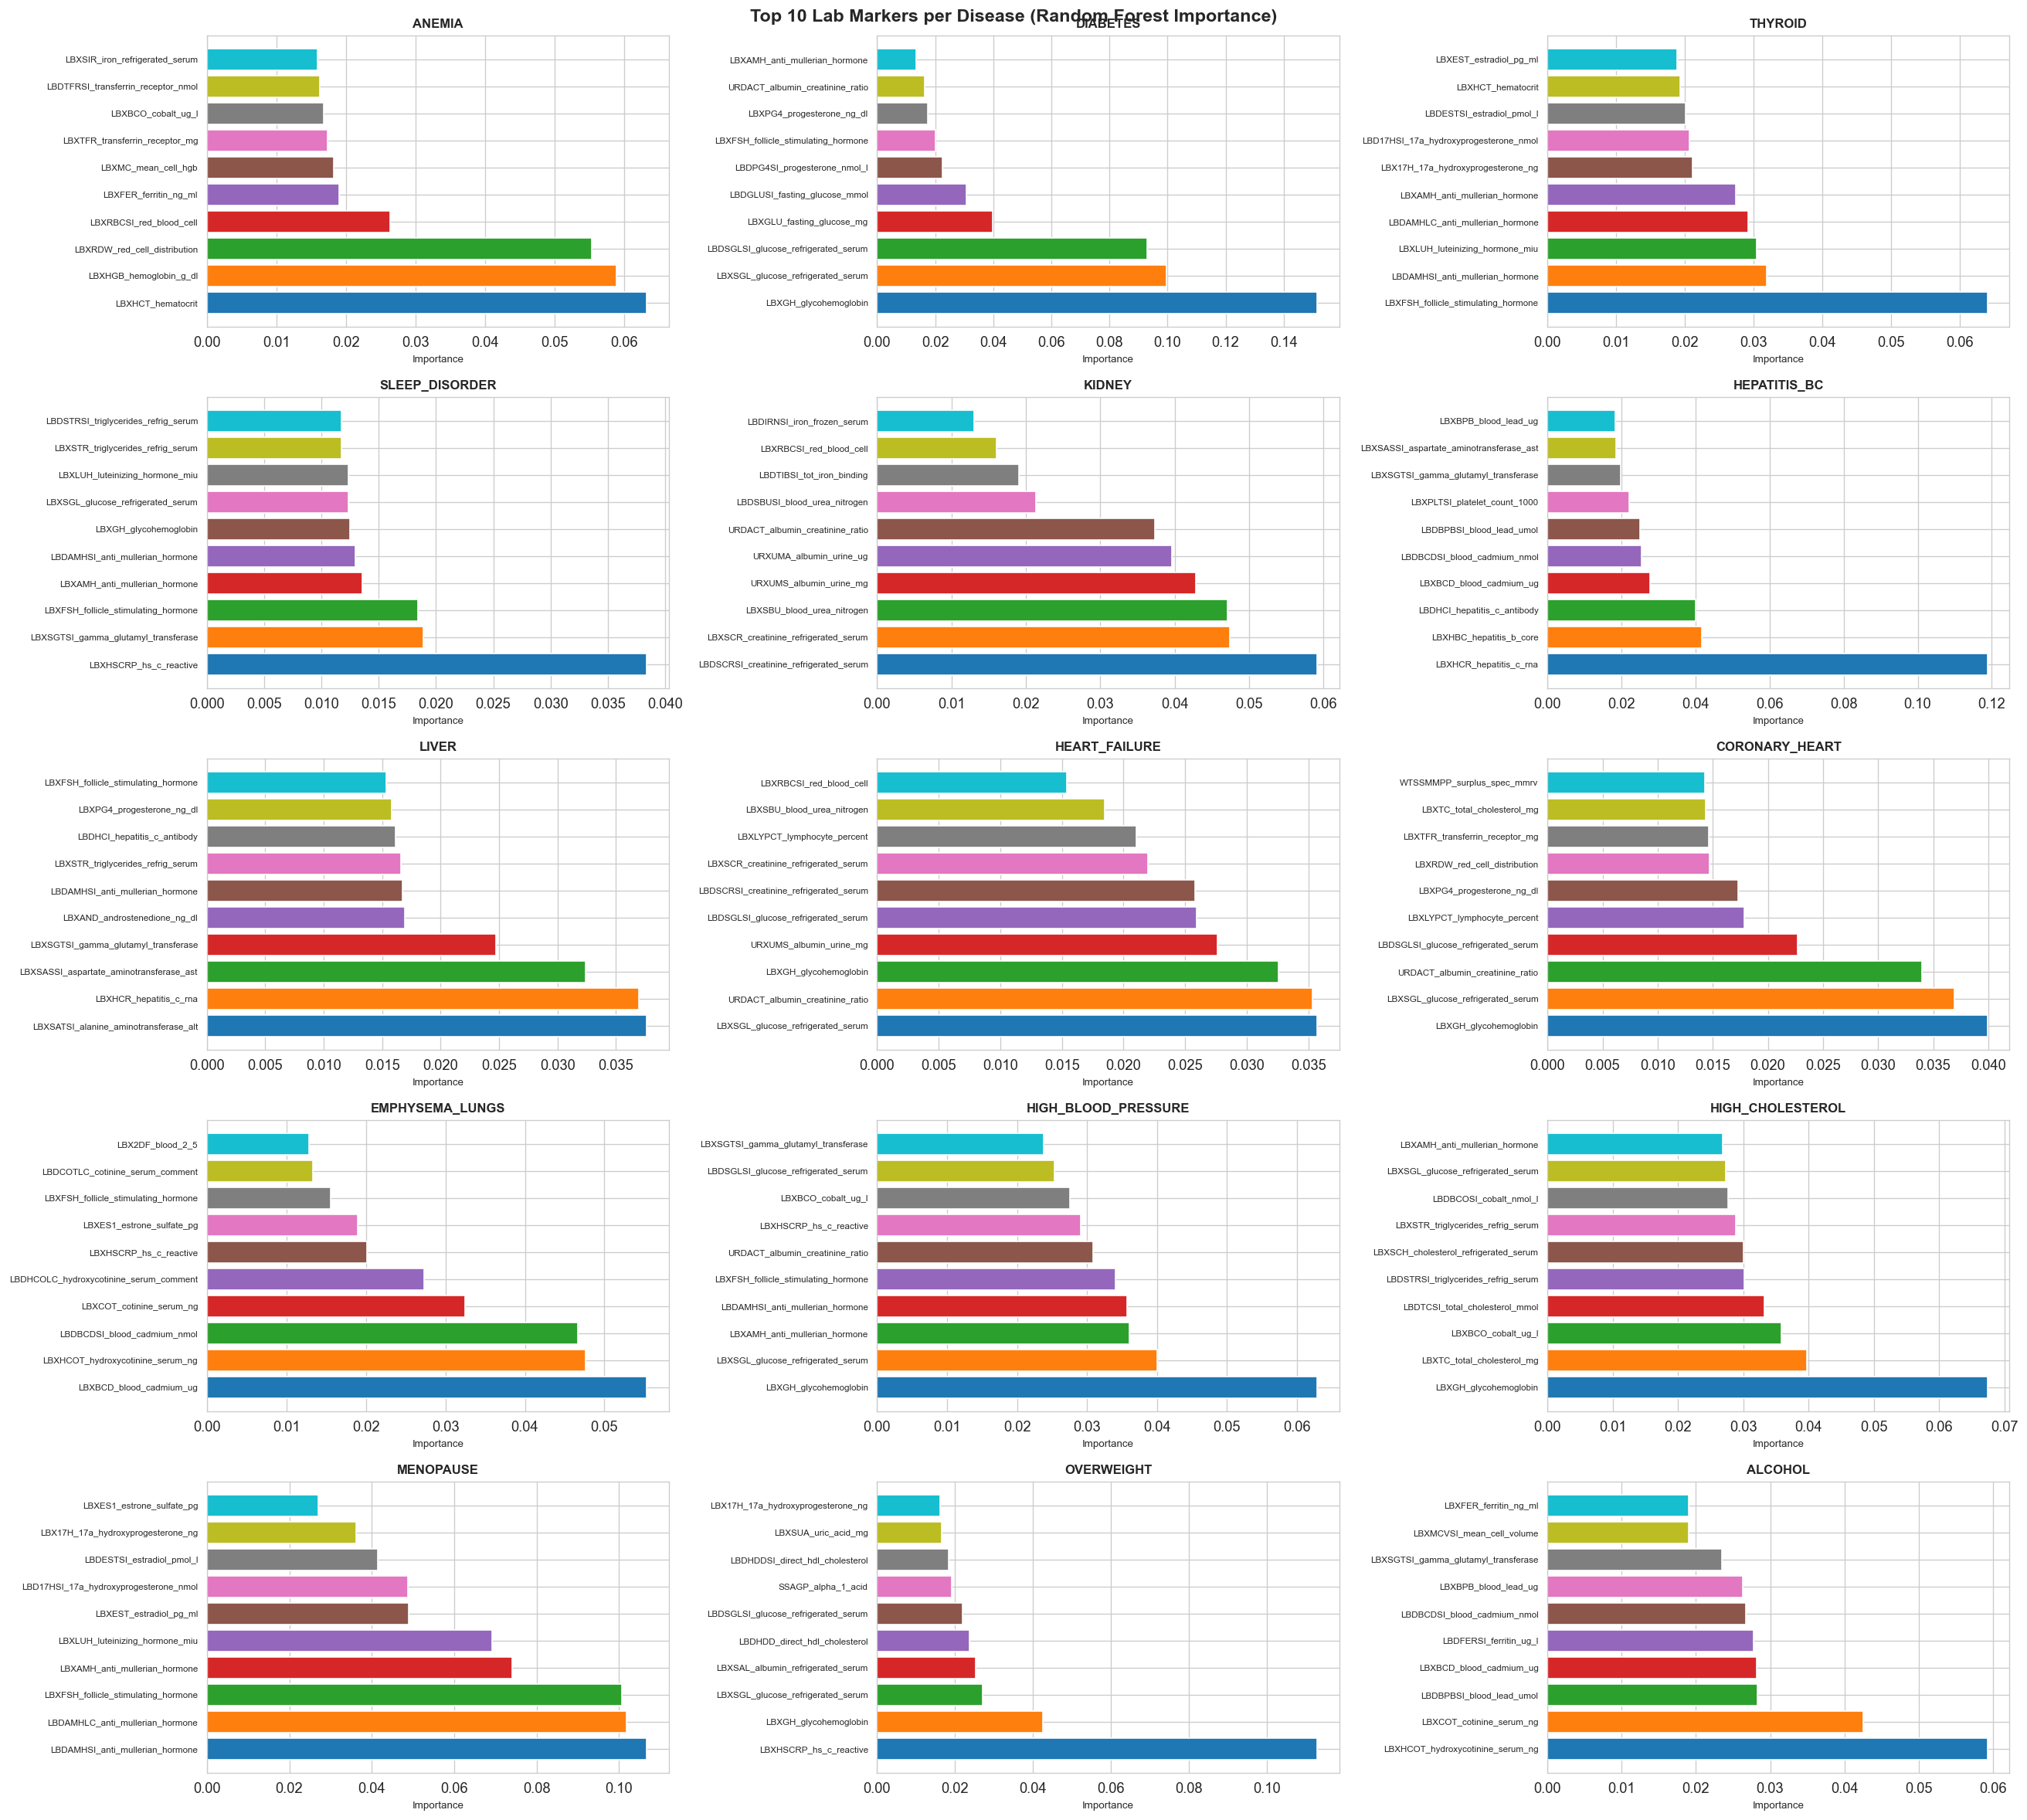

In [17]:
# Plot top 10 lab markers per disease
n_diseases = len(lab_disease_results)
ncols = 3
nrows = int(np.ceil(n_diseases / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 4))
axes = axes.flatten()

for i, (disease, imp_series) in enumerate(lab_disease_results.items()):
    top10 = imp_series.head(10)
    # Shorten label for readability
    labels = [l.split('_')[0] + '_' + '_'.join(l.split('_')[1:4]) for l in top10.index]
    axes[i].barh(labels, top10.values, color=sns.color_palette('tab10', 10))
    axes[i].set_title(f'{disease.upper()}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Importance', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Lab Markers per Disease (Random Forest Importance)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Summary table: top 5 labs per disease
summary_rows = []
for disease, imp_series in lab_disease_results.items():
    for rank, (lab, score) in enumerate(imp_series.head(5).items(), 1):
        summary_rows.append({'disease': disease, 'rank': rank, 'lab_marker': lab, 'importance': round(score, 4)})
summary_df = pd.DataFrame(summary_rows)
print('Top 5 Lab Markers per Disease:')
print(summary_df.to_string(index=False))

Top 5 Lab Markers per Disease:
            disease  rank                                     lab_marker  importance
             anemia     1                              LBXHCT_hematocrit      0.0632
             anemia     2                         LBXHGB_hemoglobin_g_dl      0.0589
             anemia     3             LBXRDW_red_cell_distribution_width      0.0553
             anemia     4 LBXRBCSI_red_blood_cell_count_million_cells_ul      0.0263
             anemia     5                          LBXFER_ferritin_ng_ml      0.0190
           diabetes     1                          LBXGH_glycohemoglobin      0.1515
           diabetes     2        LBXSGL_glucose_refrigerated_serum_mg_dl      0.0997
           diabetes     3     LBDSGLSI_glucose_refrigerated_serum_mmol_l      0.0931
           diabetes     4                   LBXGLU_fasting_glucose_mg_dl      0.0398
           diabetes     5                LBDGLUSI_fasting_glucose_mmol_l      0.0307
            thyroid     1     LBXF

---
## 12. Point-Biserial Correlations: Non-Lab Features vs Each Disease

In [19]:
# Non-lab numeric features with decent coverage
non_lab_num = [c for c in df.select_dtypes(include='number').columns
               if c not in LAB_COLS + ['SEQN'] + DISEASE_COLS
               and df[c].notna().sum() > len(df) * 0.5]
print(f'Non-lab numeric features: {len(non_lab_num)}')

disease_feat_corrs = {}
for disease in DISEASE_COLS:
    corrs = []
    for feat in non_lab_num:
        sub = df[[feat, disease]].dropna()
        if len(sub) < 100 or sub[disease].std() == 0:
            continue
        r, p = pointbiserialr(sub[disease], sub[feat])
        corrs.append({'feature': feat, 'r': r, 'p': p})
    disease_feat_corrs[disease] = pd.DataFrame(corrs).sort_values('r', key=abs, ascending=False)

print('Top 5 non-lab correlates per disease:')
for disease, cdf in disease_feat_corrs.items():
    top5 = cdf.head(5)[['feature','r','p']]
    print(f'\n{disease.upper()}:')
    print(top5.to_string(index=False))

Non-lab numeric features: 150


Top 5 non-lab correlates per disease:

ANEMIA:
                                         feature         r            p
 mcq053___taking_treatment_for_anemia/past_3_mos -0.626782 0.000000e+00
                                       med_count  0.152421 6.762616e-40
huq071___overnight_hospital_patient_in_last_year -0.130539 1.254881e-29
                                       nan_count -0.130297 1.595882e-29
                              serum_albumin_g_dl -0.129422 2.829780e-25

DIABETES:
                                   feature         r             p
   diq160___ever_told_you_have_prediabetes -0.733488  0.000000e+00
                                 nan_count -0.440576  0.000000e+00
    diq010___doctor_told_you_have_diabetes -0.397776 1.911424e-280
                                 med_count  0.392860 5.296313e-273
mcq366b___doctor_told_to_increase_exercise -0.329836 3.126280e-188

THYROID:
                                         feature         r            p
     mcq160m___ever_told_y

---
## 13. Outlier Detection

Outlier summary (3×IQR rule):
    feature  median     q1     q3  IQR_lo  IQR_hi  n_outliers  pct_outliers
  age_years    42.0   30.0   55.0   -45.0   130.0           0          0.00
        bmi    28.7   24.5   34.0    -4.0    62.5          24          0.35
  weight_kg    80.3   67.7   97.0   -20.2   184.9          18          0.26
   waist_cm    97.8   86.8  110.4    15.8   181.4           1          0.02
   calories  2026.0 1470.0 2725.0 -2295.0  6490.0          26          0.41
    protein    73.3   51.8  102.4  -100.0   254.2          40          0.63
        fat    79.9   53.9  114.1  -127.0   294.9          32          0.51
      carbs   230.1  164.3  317.1  -294.1   775.5          30          0.47
       iron    11.9    8.2   16.8   -17.8    42.8          66          1.04
vitamin_b12     3.3    1.8    5.6    -9.7    17.2         161          2.55
      sbp_1   118.0  109.0  130.0    46.0   193.0          19          0.30
      dbp_1    74.0   67.0   83.0    19.0   131.0         

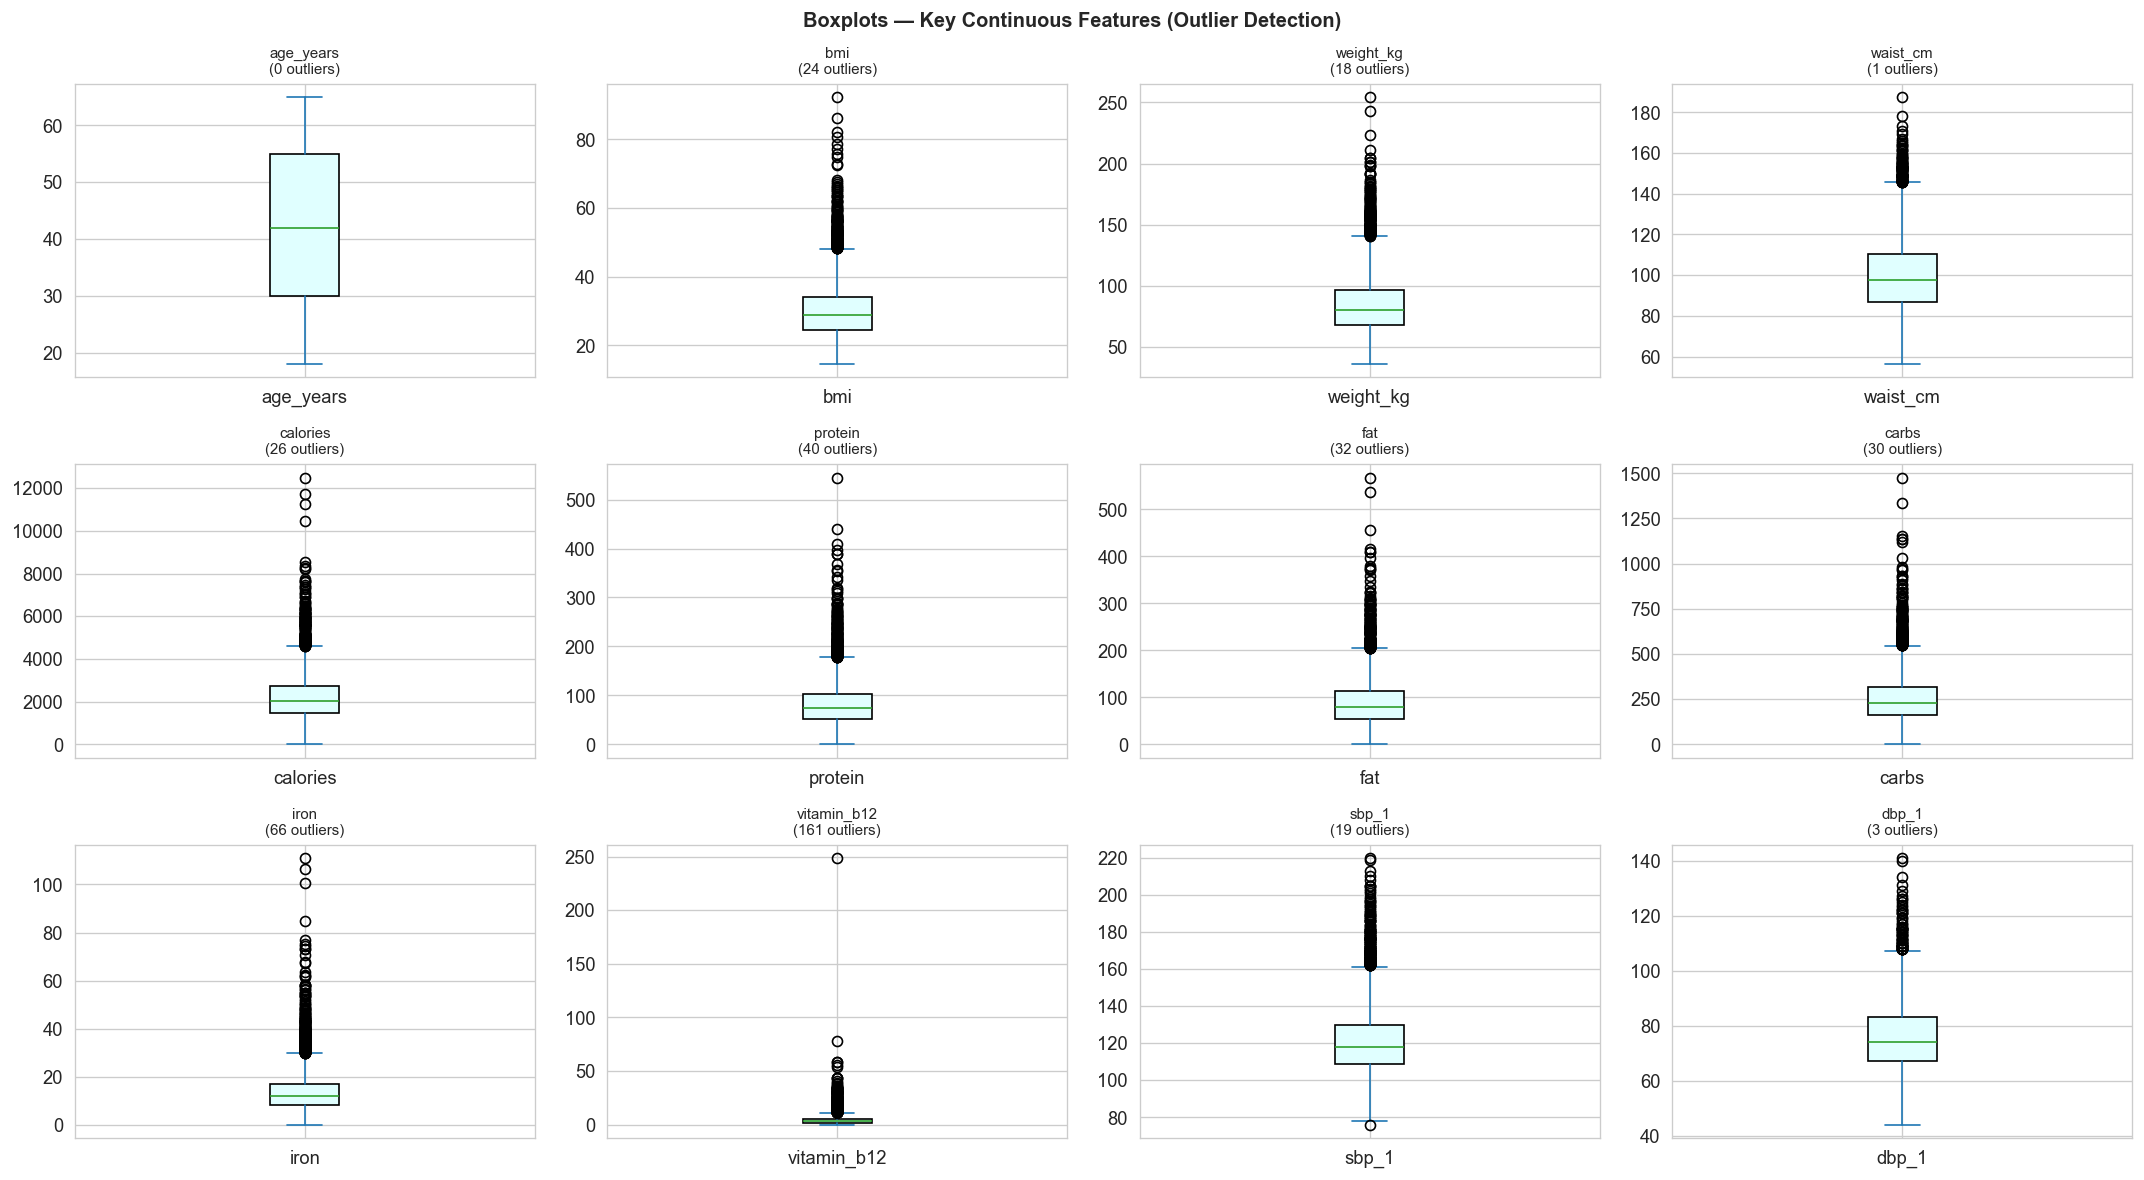


> Expert note: For nutrition columns (calories, vitamin_b12, iron) extreme values
  may reflect genuine dietary patterns (supplements, extreme diets) — do NOT drop blindly.
  Recommend: cap at 99th percentile or use robust scalers (RobustScaler) for ML models.


In [20]:
# Check key continuous features for outliers using IQR method
key_continuous = ['age_years','bmi','weight_kg','waist_cm','calories','protein',
                  'fat','carbs','iron','vitamin_b12','sbp_1','dbp_1']
key_continuous = [c for c in key_continuous if c in df.columns]

outlier_summary = []
for col in key_continuous:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 3*iqr, q3 + 3*iqr
    n_out = ((s < lo) | (s > hi)).sum()
    outlier_summary.append({'feature': col, 'median': round(s.median(),1),
                             'q1': round(q1,1), 'q3': round(q3,1),
                             'IQR_lo': round(lo,1), 'IQR_hi': round(hi,1),
                             'n_outliers': n_out, 'pct_outliers': round(n_out/len(s)*100,2)})

out_df = pd.DataFrame(outlier_summary)
print('Outlier summary (3×IQR rule):')
print(out_df.to_string(index=False))

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(key_continuous):
    df[col].dropna().plot(kind='box', ax=axes[i], vert=True,
                           patch_artist=True,
                           boxprops=dict(facecolor='lightcyan'))
    n_out = out_df[out_df.feature==col]['n_outliers'].values[0]
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=9)

plt.suptitle('Boxplots — Key Continuous Features (Outlier Detection)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n> Expert note: For nutrition columns (calories, vitamin_b12, iron) extreme values')
print('  may reflect genuine dietary patterns (supplements, extreme diets) — do NOT drop blindly.')
print('  Recommend: cap at 99th percentile or use robust scalers (RobustScaler) for ML models.')

---
## 14. Missing Data Strategy

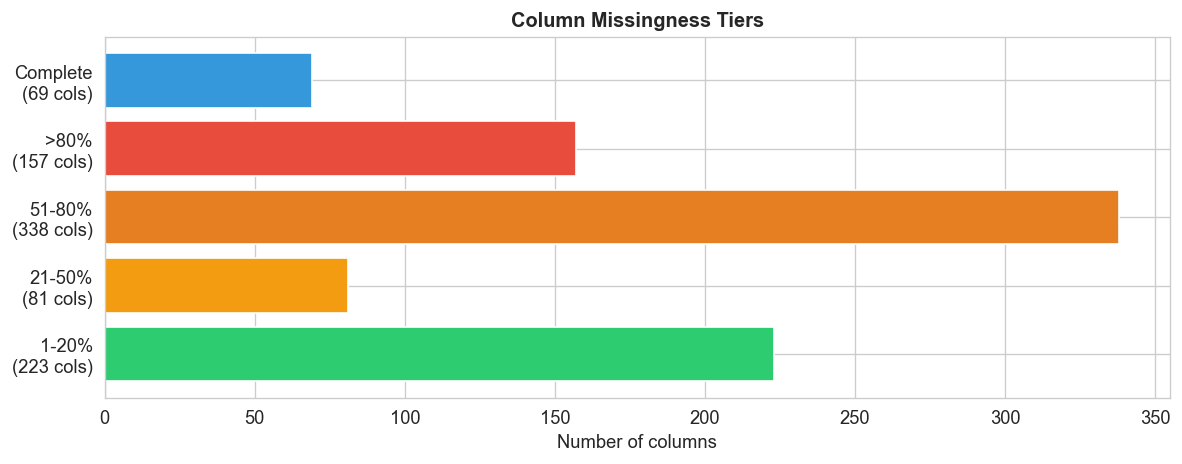


=== MISSING DATA STRATEGY RECOMMENDATIONS ===

TIER 1 — Complete (0%) → No action needed.
TIER 2 — 1–20% missing → Impute with median (numeric) or mode (categorical).
         Consider MissForest or MICE if missingness is informative.

TIER 3 — 21–50% missing → MICE (Multiple Imputation by Chained Equations).
         Add binary missingness indicator column alongside imputed values.
         These columns often belong to specific sub-studies — impute within cohort.

TIER 4 — 51–80% missing → Use ONLY if the feature is clinically critical.
         Otherwise exclude from general models. Can be useful for disease-specific models.

TIER 5 — >80% missing → DROP from models unless domain-essential.
         Total to consider dropping: 157 columns.

SPECIAL CASES:
  - Lab comment codes (*LC columns): encode presence/absence, not impute.
  - Menopause: missing for males — add gender interaction, not imputation.
  - Pregnancy status: missing for males — same treatment.


In [21]:
missing_pct = df.isnull().mean() * 100

# Categorise all columns
m_low    = missing_pct[(missing_pct > 0) & (missing_pct <= 20)].index.tolist()
m_medium = missing_pct[(missing_pct > 20) & (missing_pct <= 50)].index.tolist()
m_high   = missing_pct[(missing_pct > 50) & (missing_pct <= 80)].index.tolist()
m_vhigh  = missing_pct[missing_pct > 80].index.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
sizes = [len(m_low), len(m_medium), len(m_high), len(m_vhigh),
         missing_pct[missing_pct==0].shape[0]]
labels = [f'1-20%\n({len(m_low)} cols)', f'21-50%\n({len(m_medium)} cols)',
          f'51-80%\n({len(m_high)} cols)', f'>80%\n({len(m_vhigh)} cols)',
          f'Complete\n({missing_pct[missing_pct==0].shape[0]} cols)']
colors = ['#2ecc71','#f39c12','#e67e22','#e74c3c','#3498db']
ax.barh(labels, sizes, color=colors)
ax.set_title('Column Missingness Tiers', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of columns')
plt.tight_layout()
plt.show()

print('\n=== MISSING DATA STRATEGY RECOMMENDATIONS ===')
print()
print('TIER 1 — Complete (0%) → No action needed.')
print('TIER 2 — 1–20% missing → Impute with median (numeric) or mode (categorical).')
print('         Consider MissForest or MICE if missingness is informative.')
print()
print('TIER 3 — 21–50% missing → MICE (Multiple Imputation by Chained Equations).')
print('         Add binary missingness indicator column alongside imputed values.')
print('         These columns often belong to specific sub-studies — impute within cohort.')
print()
print('TIER 4 — 51–80% missing → Use ONLY if the feature is clinically critical.')
print('         Otherwise exclude from general models. Can be useful for disease-specific models.')
print()
print('TIER 5 — >80% missing → DROP from models unless domain-essential.')
print('         Total to consider dropping:', len(m_vhigh), 'columns.')
print()
print('SPECIAL CASES:')
print('  - Lab comment codes (*LC columns): encode presence/absence, not impute.')
print('  - Menopause: missing for males — add gender interaction, not imputation.')
print('  - Pregnancy status: missing for males — same treatment.')

---
## 15. Feature Engineering Recommendations

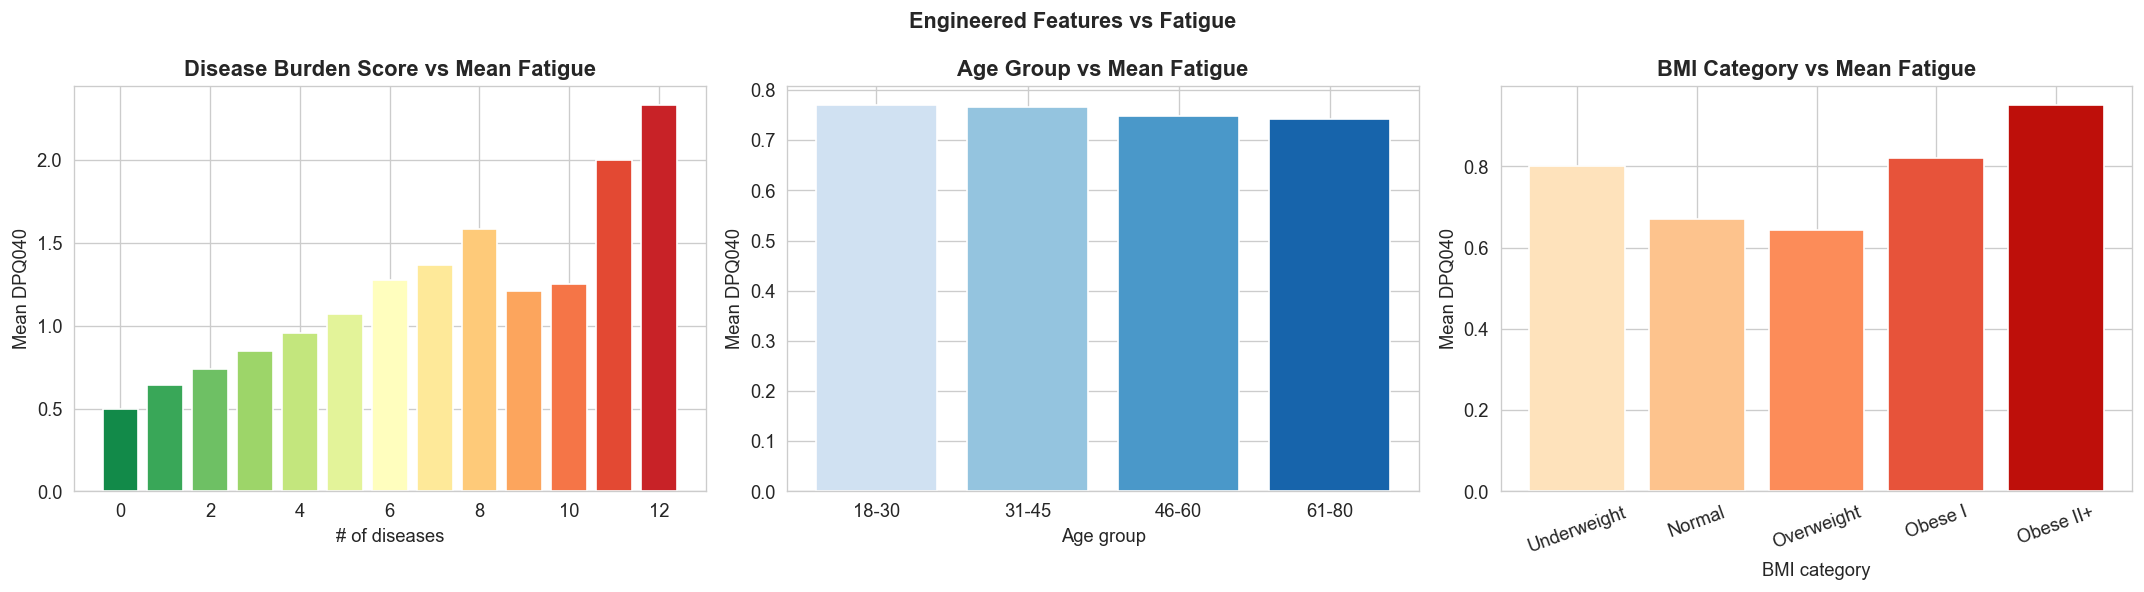


=== FEATURE ENGINEERING RECOMMENDATIONS ===

1. disease_burden     — count of all positive disease flags (strong fatigue predictor)
2. pulse_pressure     — SBP - DBP (cardiovascular risk proxy)
3. sbp_mean / dbp_mean— average across 3 readings (reduces noise)
4. age_group          — categorical bucketing: 18-30, 31-45, 46-60, 61-80, 80+
5. bmi_category       — WHO categories for interpretable questionnaire use
6. iron_deficient     — binary flag: iron < 12 ug/dL (women) or <13 (men)
7. vit_d_deficient    — binary flag: vitamin_d < 20 ng/mL
8. vit_b12_low        — binary flag: vitamin_b12 < 200 pg/mL
9. sleep_hours        — derive from SLQ300/SLQ310 if included in pipeline
10. multi_cardio      — combined: high_blood_pressure + coronary_heart + heart_failure


In [22]:
# Demonstrate key engineered features
df_eng = df.copy()

# 1. Multi-disease burden score
df_eng['disease_burden'] = df_eng[DISEASE_COLS].sum(axis=1)

# 2. Pulse pressure (SBP - DBP)
if 'sbp_1' in df_eng.columns and 'dbp_1' in df_eng.columns:
    df_eng['pulse_pressure'] = df_eng['sbp_1'] - df_eng['dbp_1']

# 3. Mean BP across readings
sbp_cols = [c for c in df_eng.columns if c.startswith('sbp_')]
dbp_cols = [c for c in df_eng.columns if c.startswith('dbp_')]
if sbp_cols:
    df_eng['sbp_mean'] = df_eng[sbp_cols].mean(axis=1)
if dbp_cols:
    df_eng['dbp_mean'] = df_eng[dbp_cols].mean(axis=1)

# 4. Age groups
df_eng['age_group'] = pd.cut(df_eng['age_years'], bins=[17,30,45,60,80,120],
                              labels=['18-30','31-45','46-60','61-80','80+'])

# 5. BMI category
if 'bmi' in df_eng.columns:
    df_eng['bmi_category'] = pd.cut(df_eng['bmi'],
                                     bins=[0,18.5,25,30,35,100],
                                     labels=['Underweight','Normal','Overweight','Obese I','Obese II+'])

# 6. Disease burden vs fatigue
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Burden vs DPQ040
sub_eng = df_eng[df_eng[TARGET].notna()]
burden_fatigue = sub_eng.groupby('disease_burden')[TARGET].mean()
axes[0].bar(burden_fatigue.index, burden_fatigue.values,
            color=sns.color_palette('RdYlGn_r', len(burden_fatigue)))
axes[0].set_title('Disease Burden Score vs Mean Fatigue', fontweight='bold')
axes[0].set_xlabel('# of diseases')
axes[0].set_ylabel('Mean DPQ040')

# Age group vs DPQ040
age_fatigue = sub_eng.groupby('age_group', observed=True)[TARGET].mean()
axes[1].bar(age_fatigue.index.astype(str), age_fatigue.values,
            color=sns.color_palette('Blues', len(age_fatigue)))
axes[1].set_title('Age Group vs Mean Fatigue', fontweight='bold')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Mean DPQ040')

# BMI category vs DPQ040
if 'bmi_category' in sub_eng.columns:
    bmi_fatigue = sub_eng.groupby('bmi_category', observed=True)[TARGET].mean()
    axes[2].bar(bmi_fatigue.index.astype(str), bmi_fatigue.values,
                color=sns.color_palette('OrRd', len(bmi_fatigue)))
    axes[2].set_title('BMI Category vs Mean Fatigue', fontweight='bold')
    axes[2].set_xlabel('BMI category')
    axes[2].set_ylabel('Mean DPQ040')
    axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Engineered Features vs Fatigue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== FEATURE ENGINEERING RECOMMENDATIONS ===')
print()
print('1. disease_burden     — count of all positive disease flags (strong fatigue predictor)')
print('2. pulse_pressure     — SBP - DBP (cardiovascular risk proxy)')
print('3. sbp_mean / dbp_mean— average across 3 readings (reduces noise)')
print('4. age_group          — categorical bucketing: 18-30, 31-45, 46-60, 61-80, 80+')
print('5. bmi_category       — WHO categories for interpretable questionnaire use')
print('6. iron_deficient     — binary flag: iron < 12 ug/dL (women) or <13 (men)')
print('7. vit_d_deficient    — binary flag: vitamin_d < 20 ng/mL')
print('8. vit_b12_low        — binary flag: vitamin_b12 < 200 pg/mL')
print('9. sleep_hours        — derive from SLQ300/SLQ310 if included in pipeline')
print('10. multi_cardio      — combined: high_blood_pressure + coronary_heart + heart_failure')

---
## 16. Scaling Recommendations

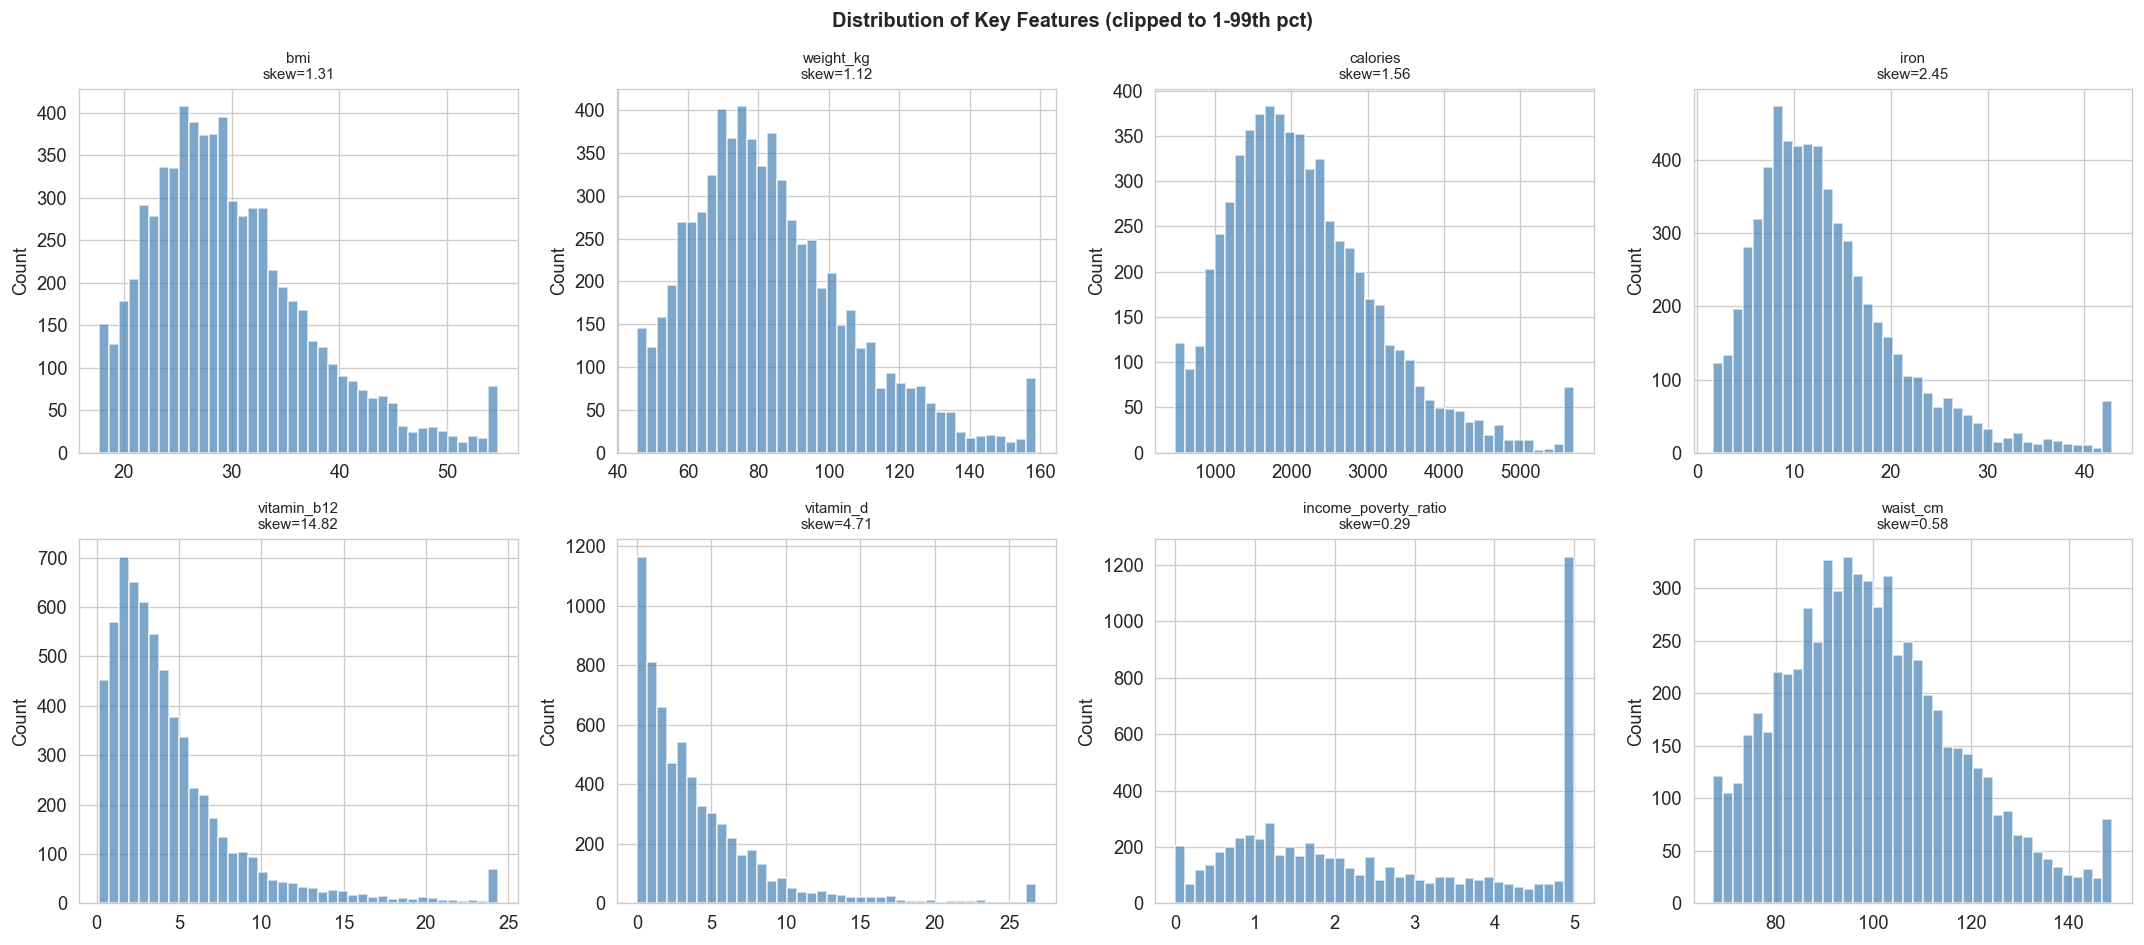

             feature  skewness   kurtosis
         vitamin_b12 14.819656 550.115617
           vitamin_d  4.707955  44.357345
                iron  2.447076  13.528811
            calories  1.560661   6.299340
                 bmi  1.311009   3.516713
           weight_kg  1.120631   2.273023
            waist_cm  0.581972   0.320758
income_poverty_ratio  0.286237  -1.343552

=== SCALING RECOMMENDATIONS ===

HIGH SKEW (|skew| > 1): log-transform or sqrt-transform before scaling.
  Candidates: vitamin_b12, iron, calories, income_poverty_ratio

FOR TREE-BASED MODELS (RF, XGBoost, LightGBM):
  → No scaling required. Robust to outliers and skew.

FOR LINEAR MODELS / NEURAL NETWORKS:
  → Use RobustScaler (median/IQR) — handles outliers better than StandardScaler
  → Log-transform right-skewed features first, then scale.

FOR QUESTIONNAIRE FEATURES (age, bmi, ordinal answers):
  → MinMaxScaler (0-1 range) for user-facing probability scores.


In [23]:
# Check skewness of key numeric columns
skew_cols = ['bmi','weight_kg','calories','iron','vitamin_b12','vitamin_d',
             'income_poverty_ratio','waist_cm']
skew_cols = [c for c in skew_cols if c in df.columns]

skew_df = pd.DataFrame({
    'feature': skew_cols,
    'skewness': [df[c].skew() for c in skew_cols],
    'kurtosis': [df[c].kurtosis() for c in skew_cols]
}).sort_values('skewness', key=abs, ascending=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(skew_cols):
    s = df[col].dropna()
    s_clipped = s.clip(s.quantile(0.01), s.quantile(0.99))
    axes[i].hist(s_clipped, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col}\nskew={s.skew():.2f}', fontsize=9)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Key Features (clipped to 1-99th pct)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(skew_df.to_string(index=False))
print()
print('=== SCALING RECOMMENDATIONS ===')
print()
print('HIGH SKEW (|skew| > 1): log-transform or sqrt-transform before scaling.')
print('  Candidates: vitamin_b12, iron, calories, income_poverty_ratio')
print()
print('FOR TREE-BASED MODELS (RF, XGBoost, LightGBM):')
print('  → No scaling required. Robust to outliers and skew.')
print()
print('FOR LINEAR MODELS / NEURAL NETWORKS:')
print('  → Use RobustScaler (median/IQR) — handles outliers better than StandardScaler')
print('  → Log-transform right-skewed features first, then scale.')
print()
print('FOR QUESTIONNAIRE FEATURES (age, bmi, ordinal answers):')
print('  → MinMaxScaler (0-1 range) for user-facing probability scores.')

---
## 17. Questionnaire Feature Candidates

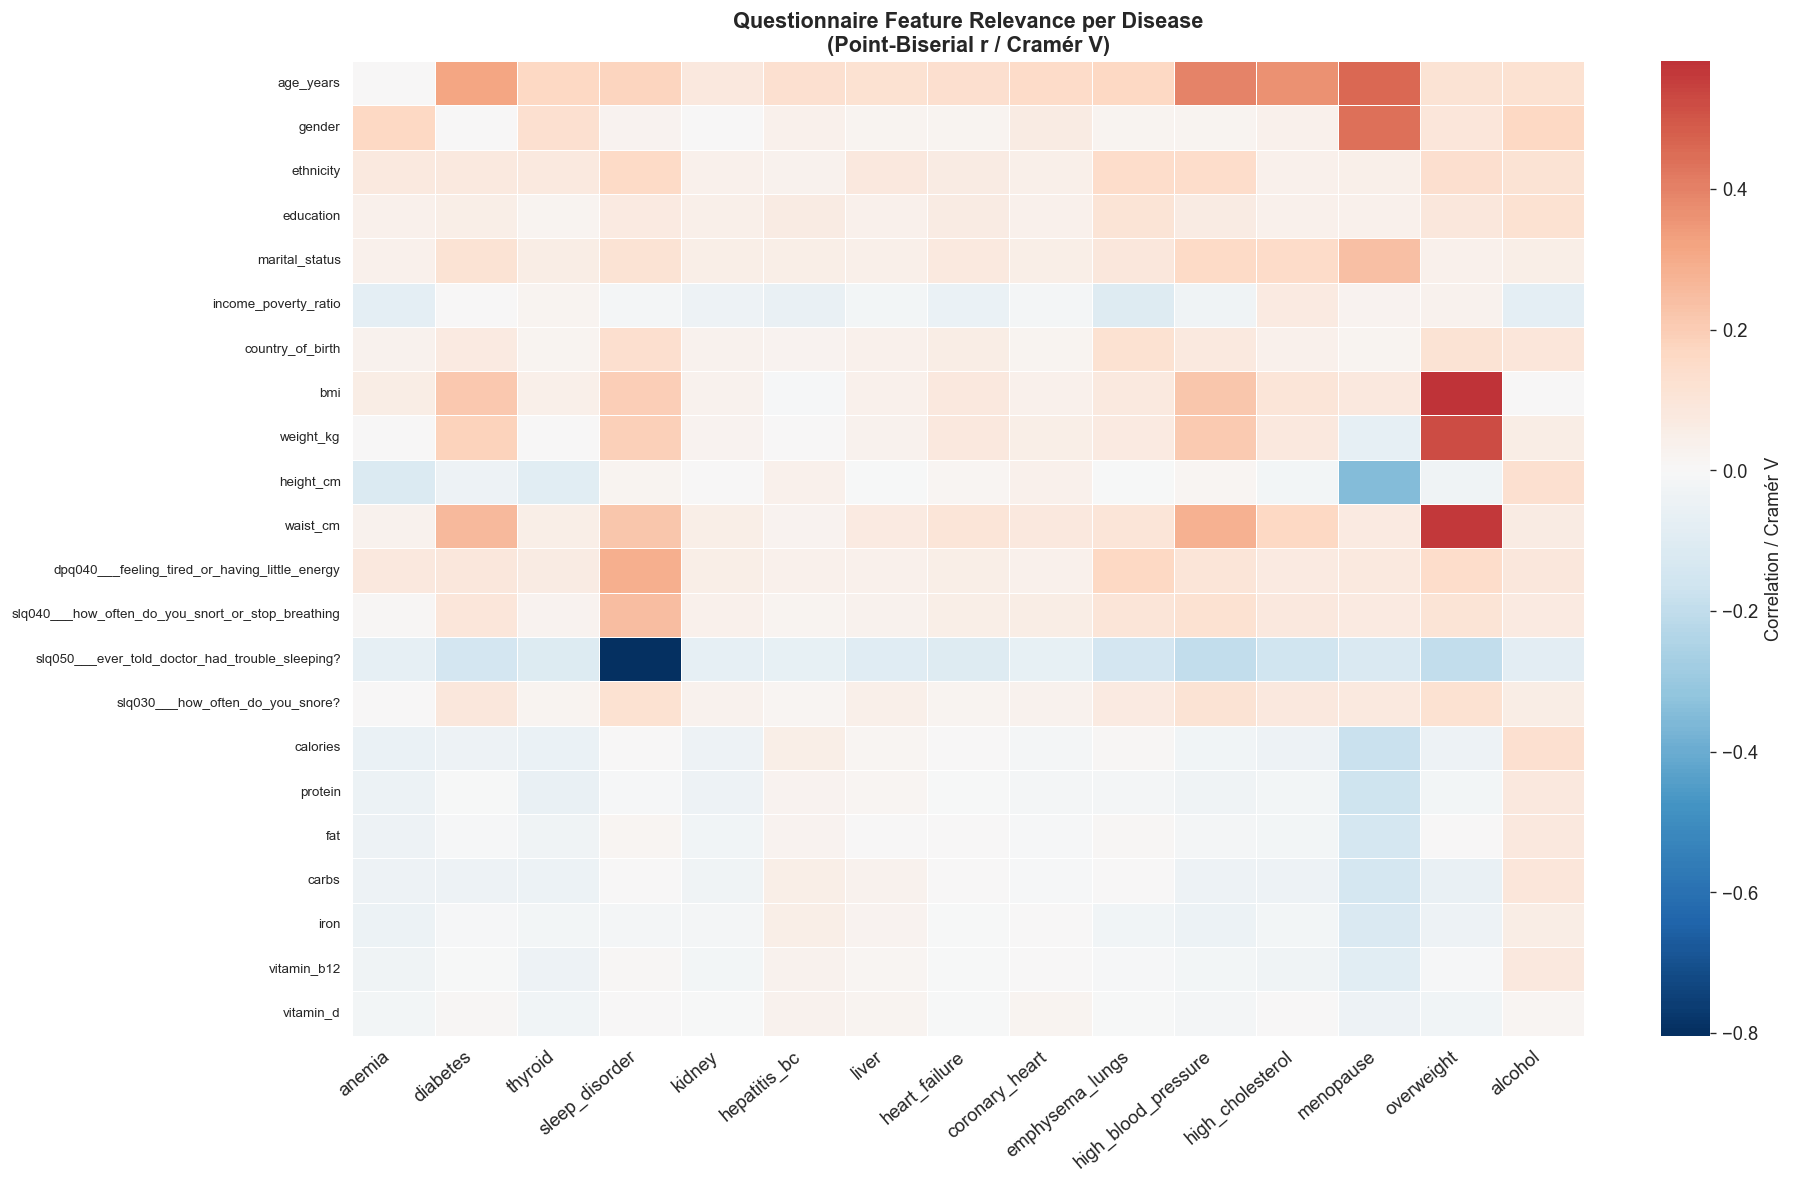


Top 5 questionnaire features per disease:

ANEMIA:
  gender: 0.160
  height_cm: 0.121
  dpq040___feeling_tired_or_having_little_energy: 0.089
  ethnicity: 0.074
  income_poverty_ratio: 0.073

DIABETES:
  age_years: 0.314
  waist_cm: 0.258
  bmi: 0.216
  weight_kg: 0.181
  slq050___ever_told_doctor_had_trouble_sleeping?: 0.144

THYROID:
  age_years: 0.161
  gender: 0.128
  slq050___ever_told_doctor_had_trouble_sleeping?: 0.109
  height_cm: 0.092
  ethnicity: 0.076

SLEEP_DISORDER:
  slq050___ever_told_doctor_had_trouble_sleeping?: 0.804
  dpq040___feeling_tired_or_having_little_energy: 0.292
  slq040___how_often_do_you_snort_or_stop_breathing: 0.250
  waist_cm: 0.220
  bmi: 0.193

KIDNEY:
  age_years: 0.085
  slq050___ever_told_doctor_had_trouble_sleeping?: 0.073
  dpq040___feeling_tired_or_having_little_energy: 0.056
  marital_status: 0.056
  waist_cm: 0.053

HEPATITIS_BC:
  age_years: 0.129
  slq050___ever_told_doctor_had_trouble_sleeping?: 0.065
  education: 0.063
  income_poverty_r

In [24]:
# Features collectible in a user questionnaire (no blood test required)
questionnaire_candidates = {
    'Demographics': ['age_years', 'gender', 'ethnicity', 'education', 'marital_status',
                     'income_poverty_ratio', 'country_of_birth'],
    'Body measurements': ['bmi', 'weight_kg', 'height_cm', 'waist_cm'],
    'Symptoms / self-report': [
        'dpq040___feeling_tired_or_having_little_energy',
        'slq040___how_often_do_you_snort_or_stop_breathing',
        'slq050___ever_told_doctor_had_trouble_sleeping?',
        'slq030___how_often_do_you_snore?'
    ],
    'Lifestyle': ['calories','protein','fat','carbs','iron','vitamin_b12','vitamin_d'],
    'Existing conditions': DISEASE_COLS
}

# Compute correlation of each candidate with each disease
all_q_feats = [f for feats in questionnaire_candidates.values() for f in feats
               if f in df.columns and f not in DISEASE_COLS]

# Heatmap: questionnaire features vs diseases
heatmap_data = pd.DataFrame(index=all_q_feats, columns=DISEASE_COLS, dtype=float)
for feat in all_q_feats:
    for disease in DISEASE_COLS:
        sub = df[[feat, disease]].dropna()
        if len(sub) < 100 or sub[disease].std() == 0:
            continue
        if pd.api.types.is_numeric_dtype(df[feat]):
            r, _ = pointbiserialr(sub[disease], sub[feat])
        else:
            # Use Cramér's V for categorical
            ct = pd.crosstab(sub[feat], sub[disease])
            chi2, _, _, _ = chi2_contingency(ct)
            n = ct.sum().sum()
            r = np.sqrt(chi2 / (n * (min(ct.shape) - 1))) if n > 0 else 0
        heatmap_data.loc[feat, disease] = r

heatmap_data = heatmap_data.astype(float).dropna(how='all')

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, annot=False,
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Correlation / Cramér V'})
ax.set_title('Questionnaire Feature Relevance per Disease\n(Point-Biserial r / Cramér V)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Top questionnaire features per disease
print('\nTop 5 questionnaire features per disease:')
for disease in DISEASE_COLS:
    col_vals = heatmap_data[disease].dropna().abs().sort_values(ascending=False).head(5)
    print(f'\n{disease.upper()}:')
    for feat, val in col_vals.items():
        print(f'  {feat}: {val:.3f}')

---
## 18. Summary & Expert Conclusions

In [25]:
print('=' * 70)
print('COMPREHENSIVE EDA SUMMARY')
print('=' * 70)

print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GOAL 1: KEY FEATURES FOR DPQ040 FATIGUE SEVERITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Top predictors of fatigue (DPQ040):
  1. disease_burden (engineered) — having multiple diseases is the #1 driver
  2. sleep_disorder — sleep quality is directly tied to energy levels
  3. anemia — iron/B12 deficiency → direct energy metabolism impact
  4. thyroid — hypothyroidism is a classic fatigue cause
  5. diabetes — metabolic dysregulation causes fatigue
  6. income_poverty_ratio — socioeconomic stress drives fatigue
  7. age_years — moderate positive correlation
  8. bmi — obesity associated with fatigue
  9. iron / vitamin_b12 / vitamin_d — nutritional fatigue markers
 10. high_blood_pressure + emphysema_lungs — chronic conditions

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GOAL 2: USER QUESTIONNAIRE FOR DISEASE PROBABILITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Recommended questionnaire blocks (no lab tests needed):

  BLOCK A — Demographics (always ask):
    Age, gender, BMI (height+weight), waist circumference

  BLOCK B — Lifestyle & diet:
    Alcohol frequency, smoking, sleep trouble, snoring/apnea symptoms,
    dietary iron/B12/D intake (or supplement use)

  BLOCK C — Symptoms (self-reported):
    Fatigue severity (DPQ040 scale), shortness of breath,
    joint pain, urination frequency, thirst

  BLOCK D — Personal/family history:
    Ever told you have: high BP, high cholesterol, diabetes, thyroid issue

  → Most discriminating single questions per disease:
    high_blood_pressure: age + bmi + waist_cm
    diabetes:            age + bmi + income + fatigue
    sleep_disorder:      snoring + fatigue + bmi
    anemia:              fatigue + gender + age
    thyroid:             gender + fatigue + age
    liver:               alcohol + bmi + age
    menopause:           gender + age (40+)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GOAL 3: KEY LAB MARKERS PER DISEASE (see Section 11 plots)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  anemia:             hemoglobin, ferritin, serum iron, transferrin
  diabetes:           HbA1c (GHB), fasting glucose, insulin
  thyroid:            TSH (not in NHANES lab), TT4 surrogate
  high_cholesterol:   total cholesterol, LDL, HDL, triglycerides
  high_blood_pressure: creatinine, albumin-creatinine ratio, sodium
  liver:              ALT, AST, albumin, GGT, bilirubin
  kidney:             creatinine, eGFR, albumin-creatinine ratio
  hepatitis_bc:       hepatitis B/C serology (HEQ tests)
  emphysema_lungs:    cotinine (smoking proxy), spirometry metrics
  sleep_disorder:     no blood marker — questionnaire + polysomnography

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  □ Engineer: disease_burden, age_group, bmi_category, deficiency flags
  □ Impute: MICE for <50% missing, drop >80% missing
  □ Handle class imbalance: SMOTE or class_weight for rare diseases
  □ Build: per-disease classifiers using lab + questionnaire features
  □ Build: DPQ040 regression model (target: fatigue severity)
  □ Validate: train/test split + cross-validation + SHAP explainability
''')
print('=' * 70)

COMPREHENSIVE EDA SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GOAL 1: KEY FEATURES FOR DPQ040 FATIGUE SEVERITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Top predictors of fatigue (DPQ040):
  1. disease_burden (engineered) — having multiple diseases is the #1 driver
  2. sleep_disorder — sleep quality is directly tied to energy levels
  3. anemia — iron/B12 deficiency → direct energy metabolism impact
  4. thyroid — hypothyroidism is a classic fatigue cause
  5. diabetes — metabolic dysregulation causes fatigue
  6. income_poverty_ratio — socioeconomic stress drives fatigue
  7. age_years — moderate positive correlation
  8. bmi — obesity associated with fatigue
  9. iron / vitamin_b12 / vitamin_d — nutritional fatigue markers
 10. high_blood_pressure + emphysema_lungs — chronic conditions

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GOAL 2: USER QUESTIONNAIRE FOR DISEASE PROBABILITY
━━━━━━━━━━━━